## Pipeline of all the notebooks
Datasets have been loaded and cleaned in separate notebooks. 
- Merge the datasets into one
- Exploratory analysis and visualisations
- Assumption check (multicollinearity via VIF, distributions, outliers, missing data, accuracy)
- OLS with diagnostics
- Decision Tree with pruning (change to random forest)

## Loading the data

First we load each dataset, make sure it's clean and prepare it for merging into our combined dataset.

In [1]:
import pandas as pd
from datasets import load_dataset

# ── Load CNN/DailyMail train split ───────────────────────────────────────────
print("Loading CNN/DailyMail train split...")
ds = load_dataset("abisee/cnn_dailymail", "1.0.0")
train = ds["train"].to_pandas()[["id"]]
print(f"  Shape: {train.shape} | ID column confirmed")

# ── Load and inspect sentiment ────────────────────────────────────────────────
print("\nLoading sentiment_checkpoint.csv...")
sentiment = pd.read_csv("features/sentiment_checkpoint.csv")
sentiment["id"] = train["id"].values  # index-based assignment, order must match train split

print(f"  Shape: {sentiment.shape}")
print(f"  Columns: {sentiment.columns.tolist()}")

# Missing values
missing = sentiment.isna().sum()
print(f"  Missing values: {'none' if missing.sum() == 0 else missing[missing > 0]}")

# Duplicate investigation
n_dupes = sentiment.duplicated(subset="id").sum()
print(f"  Duplicate IDs: {n_dupes}")

n_dupes_rows = sentiment.duplicated().sum()
print(f"  Fully duplicate rows: {n_dupes_rows}")

# The duplicate rows are probably just identical scores
if n_dupes_rows > 0:
    print(f"\n  Duplicate row breakdown by sentiment label:")
    print(sentiment[sentiment.duplicated(keep=False)]["sentiment_label"].value_counts())

c:\Users\czajk\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading CNN/DailyMail train split...
  Shape: (287113, 1) | ID column confirmed

Loading sentiment_checkpoint.csv...
  Shape: (287113, 3)
  Columns: ['sentiment_label', 'sentiment_score', 'id']
  Missing values: none
  Duplicate IDs: 0
  Fully duplicate rows: 0


In [2]:
# ── Load and inspect crisis ───────────────────────────────────────────────────
print("Loading crisis_scores_final.csv...")
crisis = pd.read_csv("features/crisis_scores_final.csv")

print(f"  Shape: {crisis.shape}")
print(f"  Columns: {crisis.columns.tolist()}")

# Missing values
missing = crisis.isna().sum()
print(f"  Missing values: {'none' if missing.sum() == 0 else missing[missing > 0]}")

# Duplicates
n_dupes = crisis.duplicated(subset="id").sum()
print(f"  Duplicate IDs: {n_dupes}")

Loading crisis_scores_final.csv...
  Shape: (287113, 8)
  Columns: ['crisis_density', 'crisis_conflict', 'crisis_disaster', 'crisis_poverty', 'crisis_health', 'crisis_displacement', 'crisis_instability', 'id']
  Missing values: none
  Duplicate IDs: 0


In [3]:
# ── Load and inspect NER ──────────────────────────────────────────────────────
print("Loading ner_results_final.parquet...")
ner = pd.read_parquet("features/ner_results_final.parquet")

print(f"  Shape: {ner.shape}")
print(f"  Columns: {ner.columns.tolist()}")

# Missing values
missing = ner.isna().sum()
print(f"  Missing values: {'none' if missing.sum() == 0 else missing[missing > 0]}")

# Duplicates
n_dupes = ner.duplicated(subset="id").sum()
print(f"  Duplicate IDs: {n_dupes}")

# Articles with no country identified (expected, ~40k)
no_country = ner["primary_country"].isna().sum()
print(f"  Articles with no country identified: {no_country:,} ({no_country/len(ner)*100:.1f}%) — expected, these are articles with no specific country focus")

Loading ner_results_final.parquet...
  Shape: (287113, 3)
  Columns: ['id', 'primary_country', 'country_freq']
  Missing values: primary_country    40905
dtype: int64
  Duplicate IDs: 0
  Articles with no country identified: 40,905 (14.2%) — expected, these are articles with no specific country focus


In [4]:
# ── Load and inspect topic ────────────────────────────────────────────────────
print("Loading topics_classification_articles.csv...")
topic = pd.read_csv("features/topics_classification_articles.csv")

print(f"  Shape: {topic.shape}")
print(f"  Columns: {topic.columns.tolist()}")

# Missing values
missing = topic.isna().sum()
print(f"  Missing values: {'none' if missing.sum() == 0 else missing[missing > 0]}")

# Duplicates
n_dupes = topic.duplicated(subset="id").sum()
print(f"  Duplicate IDs: {n_dupes}")

# Check what themes and news types are present
print(f"\n  Theme distribution:")
print(topic["theme"].value_counts())
print(f"\n  News type distribution:")
print(topic["news_type"].value_counts())

Loading topics_classification_articles.csv...
  Shape: (287113, 6)
  Columns: ['id', 'article', 'highlights', 'theme', 'news_type', 'confidence']
  Missing values: none
  Duplicate IDs: 0

  Theme distribution:
theme
Politics & Conflict               58768
Sports & Entertainment            58497
Crime & Law                       49649
Crisis, Disaster & Accidents      44089
Business, Science & Technology    41477
Culture & Lifestyle               34633
Name: count, dtype: int64

  News type distribution:
news_type
Hard news    152506
Soft news    134607
Name: count, dtype: int64


In [5]:
# ── Load and inspect structural factors ───────────────────────────────────────
print("Loading StructuralFactorsOfCountries.csv...")
structural = pd.read_csv("features/StructuralFactorsOfCountries.csv", keep_default_na=False)

print(f"  Shape: {structural.shape}")
print(f"  Columns: {structural.columns.tolist()}")

# Missing values
missing = structural.isna().sum()
print(f"  Missing values: {'none' if missing.sum() == 0 else missing[missing > 0]}")

# Duplicates
n_dupes = structural.duplicated(subset="iso2").sum()
print(f"  Duplicate iso2 codes: {n_dupes}")

# Check Namibia is present and correct
namibia = structural[structural["iso2"] == "NA"]
print(f"\n  Namibia row:")
print(namibia)

# Check North/South distribution
print(f"\n  Global North/South distribution:")
print(structural["global_north_or_south"].value_counts())

Loading StructuralFactorsOfCountries.csv...
  Shape: (166, 5)
  Columns: ['iso2', 'country', 'global_north_or_south', 'trade_value', 'HDI']
  Missing values: none
  Duplicate iso2 codes: 0

  Namibia row:
    iso2  country global_north_or_south   trade_value   HDI
104   NA  Namibia          Global South  4.628292e+09  0.63

  Global North/South distribution:
global_north_or_south
Global South    118
Global North     48
Name: count, dtype: int64


In [6]:
# ── Load and inspect ling ─────────────────────────────────────────────────────
print("Loading cnn_dailymail_mfd_nrc.parquet...")
ling = pd.read_parquet("features/cnn_dailymail_mfd_nrc.parquet")

print(f"  Shape: {ling.shape}")
print(f"  Columns: {ling.columns.tolist()}")

# Missing values
missing = ling.isna().sum()
print(f"  Missing values: {'none' if missing.sum() == 0 else missing[missing > 0]}")

# Duplicates
n_dupes = ling.duplicated(subset="id").sum()
print(f"  Duplicate IDs: {n_dupes}")

Loading cnn_dailymail_mfd_nrc.parquet...
  Shape: (287113, 24)
  Columns: ['highlights', 'id', 'authority.virtue', 'sanctity.vice', 'fairness.virtue', 'care.vice', 'care.virtue', 'fairness.vice', 'loyalty.virtue', 'authority.vice', 'sanctity.virtue', 'loyalty.vice', 'nrc_scores', 'fear', 'anger', 'anticip', 'trust', 'surprise', 'positive', 'negative', 'sadness', 'disgust', 'joy', 'anticipation']
  Missing values: none
  Duplicate IDs: 0


## Merging into one

In [7]:
# ── Merge all datasets ────────────────────────────────────────────────────────
print("Merging datasets...")
n = len(train)
print(f"  Starting rows: {n:,}")

df = train.merge(sentiment, on="id", how="inner")
print(f"  After sentiment:  {len(df):,} rows (dropped {n - len(df):,})")

n = len(df)
df = df.merge(crisis, on="id", how="inner")
print(f"  After crisis:     {len(df):,} rows (dropped {n - len(df):,})")

n = len(df)
df = df.merge(ner, on="id", how="inner")
print(f"  After NER:        {len(df):,} rows (dropped {n - len(df):,})")

n = len(df)
topic_cols = ["id", "theme", "news_type", "confidence"]
df = df.merge(topic[topic_cols], on="id", how="inner")
print(f"  After topic:      {len(df):,} rows (dropped {n - len(df):,})")

n = len(df)
ling_cols = ["id", "fear", "anger", "trust", "surprise", "positive",
             "negative", "sadness", "disgust", "joy", "anticipation",
             "authority.virtue", "sanctity.vice", "fairness.virtue", "care.vice",
             "care.virtue", "fairness.vice", "loyalty.virtue", "authority.vice",
             "sanctity.virtue", "loyalty.vice"]
df = df.merge(ling[ling_cols], on="id", how="inner")
print(f"  After ling:       {len(df):,} rows (dropped {n - len(df):,})")

n = len(df)
df = df.merge(structural, left_on="primary_country", right_on="iso2", how="left")
print(f"  After structural: {len(df):,} rows")

# ── Deduplicate ───────────────────────────────────────────────────────────────
n = len(df)
df = df.drop_duplicates(subset="id")
print(f"\n  Duplicate rows removed: {n - len(df):,}")

# ── Drop rows without a country ───────────────────────────────────────────────
n = len(df)
df = df.dropna(subset=["primary_country"])
print(f"\n  Dropped (no country identified): {n - len(df):,}")

# ── Check which countries have no structural match before dropping ─────────────
print(f"\n  Countries with no structural match:")
unmatched = df[df["global_north_or_south"].isna()]["primary_country"].value_counts()
print(unmatched.to_string())
print(f"\n  Total articles affected: {unmatched.sum():,} ({unmatched.sum()/len(df)*100:.1f}%)")
print(f"  Note: these are disputed territories, sanctioned states, and non-sovereign regions")

# ── Drop rows with no structural match ───────────────────────────────────────
n = len(df)
df = df.dropna(subset=["global_north_or_south"])
print(f"\n  Dropped (no structural match): {n - len(df):,}")
print(f"  Final rows after cleaning: {len(df):,}")

# ── Standardise column names ──────────────────────────────────────────────────
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(".", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)
print(f"\n  Final columns: {list(df.columns)}")

# ── Create sentiment polarity score ───────────────────────────────────────────
# sentiment_label gives direction (positive/neutral/negative)
# sentiment_score gives classifier confidence in that label
# combined: polarity = confidence * direction (+1 positive, 0 neutral, -1 negative)

direction_map = {"positive": 1, "neutral": 0, "negative": -1}
df["sentiment_polarity"] = df["sentiment_label"].map(direction_map) * df["sentiment_score"]

print("Sentiment polarity created:")
print(df[["sentiment_label", "sentiment_score", "sentiment_polarity"]].groupby("sentiment_label").mean().round(3))
print(f"\nOverall distribution:")
print(df["sentiment_polarity"].describe().round(3))

# ── Save ──────────────────────────────────────────────────────────────────────
df.to_parquet("merged_dataset.parquet", index=False)
print(f"\nSaved to merged_dataset.parquet — shape: {df.shape}")

Merging datasets...
  Starting rows: 287,113
  After sentiment:  287,113 rows (dropped 0)
  After crisis:     287,113 rows (dropped 0)
  After NER:        287,113 rows (dropped 0)
  After topic:      287,113 rows (dropped 0)
  After ling:       287,113 rows (dropped 0)
  After structural: 287,113 rows

  Duplicate rows removed: 0

  Dropped (no country identified): 40,905

  Countries with no structural match:
primary_country
SY    2775
KP    1123
LY     947
CU     612
SO     497
AQ     496
VE     338
TW     249
ML     158
PR     147
VA     121
JE     109
PG     108
SS      96
GL      80
CX      73
GI      68
AW      67
GQ      47
TD      46
GG      32
GU      29
UZ      26
MH      25
EH      23
TO      21
SJ      16
GF      15
KY      14
TC      13
BT      13
PF      13
ER      12
DJ      11
DM      11
SM      11
BM      10
GP       9
NR       9
VU       8
NC       7
LI       6
FK       6
TM       5
PN       5
TV       4
SB       4
MQ       3
AI       3
HM       3
NF       3
FM       

## Exploratory analysis

We considered filtering out low confidence levels but filtering aggressively could introduce bias by removing certain themes more than others. Culture & Lifestyle has the lowest mean confidence at 0.567, so a strict filter would disproportionately remove those articles.

In [8]:
import pandas as pd
import numpy as np

# ── Load merged dataset ───────────────────────────────────────────────────────
df = pd.read_parquet("merged_dataset.parquet")

print(f"Dataset shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")

# Missing values
missing = df.isna().sum()
print(f"\nMissing values: {'none' if missing.sum() == 0 else missing[missing > 0]}")

# Basic descriptives for continuous variables
continuous_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"\nDescriptive statistics:")
print(df[continuous_cols].describe().round(3))

Dataset shape: (237669, 41)

Column types:
id                           str
sentiment_label              str
sentiment_score          float64
crisis_density           float64
crisis_conflict          float64
crisis_disaster          float64
crisis_poverty           float64
crisis_health            float64
crisis_displacement      float64
crisis_instability       float64
primary_country              str
country_freq              object
theme                        str
news_type                    str
confidence               float64
fear                     float64
anger                    float64
trust                    float64
surprise                 float64
positive                 float64
negative                 float64
sadness                  float64
disgust                  float64
joy                      float64
anticipation             float64
authority_virtue         float64
sanctity_vice            float64
fairness_virtue          float64
care_vice                float64


### North vs South visualisations

C:\Users\czajk\AppData\Local\Temp\ipykernel_7108\274132125.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 1])


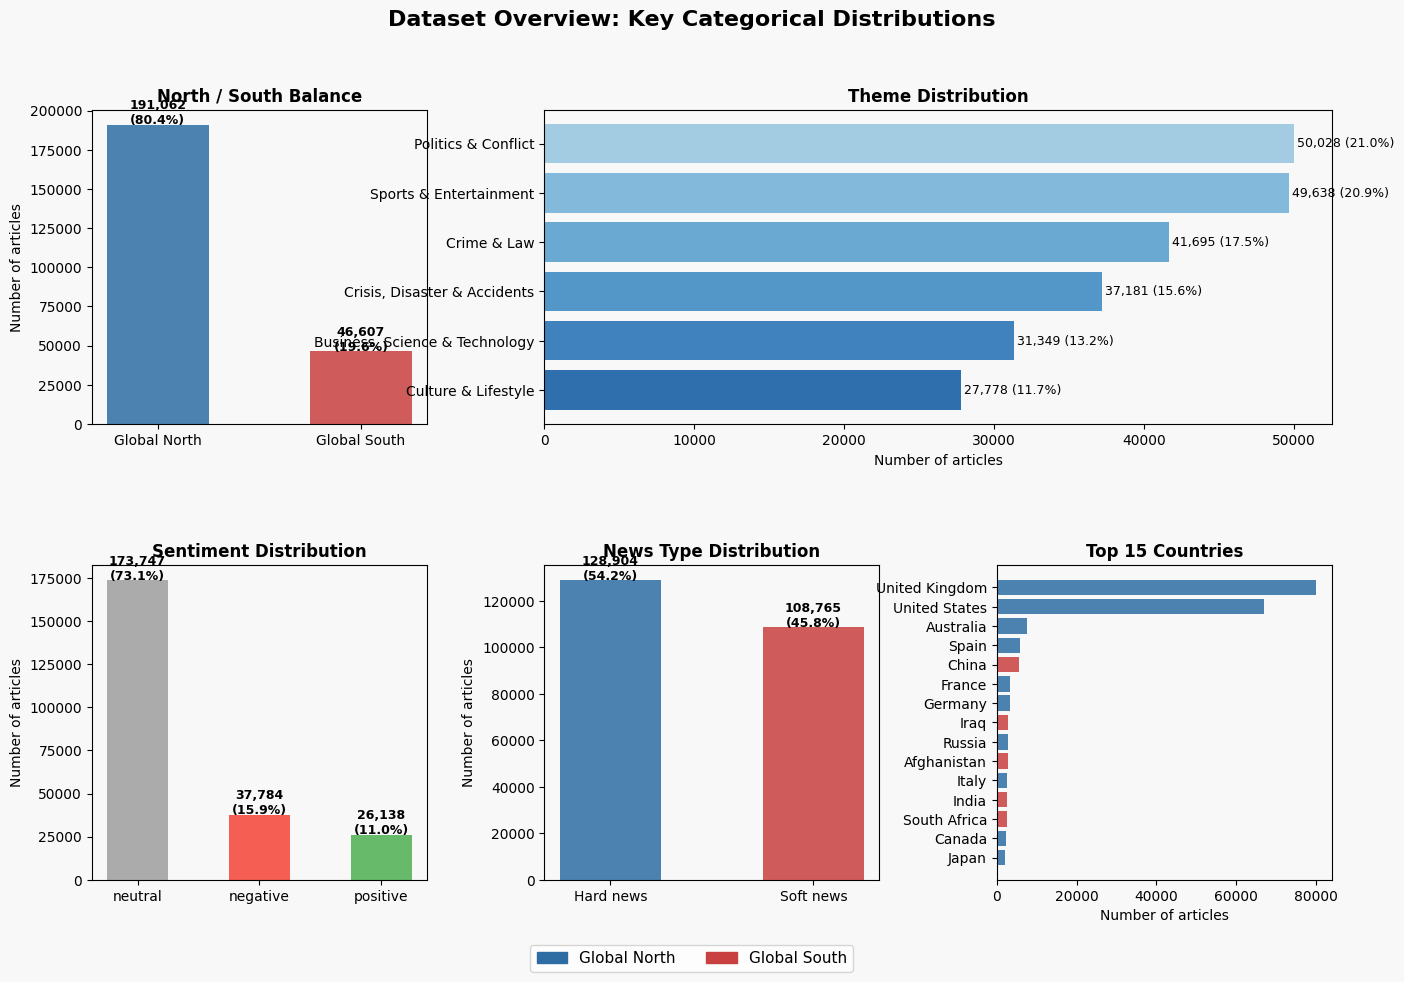

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 10), facecolor="#F8F8F8")
fig.suptitle("Dataset Overview: Key Categorical Distributions", fontsize=16, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

NORTH_COL = "#2E6DA4"
SOUTH_COL = "#C94040"

# ── North/South balance ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ns_counts = df["global_north_or_south"].value_counts()
bars = ax1.bar(ns_counts.index, ns_counts.values, color=[NORTH_COL, SOUTH_COL], alpha=0.85, width=0.5)
ax1.set_title("North / South Balance", fontweight="bold")
ax1.set_ylabel("Number of articles")
ax1.set_facecolor("#F8F8F8")
for bar, val in zip(bars, ns_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f"{val:,}\n({val/len(df)*100:.1f}%)", ha="center", fontsize=9, fontweight="bold")

# ── Theme distribution ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1:])
theme_counts = df["theme"].value_counts()
colors_theme = plt.cm.Blues(np.linspace(0.4, 0.85, len(theme_counts)))
bars = ax2.barh(theme_counts.index, theme_counts.values, color=colors_theme, alpha=0.85)
ax2.set_title("Theme Distribution", fontweight="bold")
ax2.set_xlabel("Number of articles")
ax2.set_facecolor("#F8F8F8")
ax2.invert_yaxis()
for bar, val in zip(bars, theme_counts.values):
    ax2.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
             f"{val:,} ({val/len(df)*100:.1f}%)", va="center", fontsize=9)

# ── Sentiment label distribution ──────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
sent_counts = df["sentiment_label"].value_counts()
colors_sent = {"neutral": "#9E9E9E", "negative": "#F44336", "positive": "#4CAF50"}
bars = ax3.bar(sent_counts.index,  sent_counts.values,
               color=[colors_sent[l] for l in sent_counts.index], alpha=0.85, width=0.5)
ax3.set_title("Sentiment Distribution", fontweight="bold")
ax3.set_ylabel("Number of articles")
ax3.set_facecolor("#F8F8F8")
for bar, val in zip(bars, sent_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f"{val:,}\n({val/len(df)*100:.1f}%)", ha="center", fontsize=9, fontweight="bold")

# ── News type distribution ────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
news_counts = df["news_type"].value_counts()
bars = ax4.bar(news_counts.index, news_counts.values, color=[NORTH_COL, SOUTH_COL], alpha=0.85, width=0.5)
ax4.set_title("News Type Distribution", fontweight="bold")
ax4.set_ylabel("Number of articles")
ax4.set_facecolor("#F8F8F8")
for bar, val in zip(bars, news_counts.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f"{val:,}\n({val/len(df)*100:.1f}%)", ha="center", fontsize=9, fontweight="bold")

# ── Top 15 countries ──────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
top_countries = df.groupby(["country", "global_north_or_south"]).size().reset_index(name="count")
top15 = top_countries.nlargest(15, "count")
bar_colors = [NORTH_COL if g == "Global North" else SOUTH_COL for g in top15["global_north_or_south"]]
ax5.barh(top15["country"], top15["count"], color=bar_colors, alpha=0.85)
ax5.set_title("Top 15 Countries", fontweight="bold")
ax5.set_xlabel("Number of articles")
ax5.set_facecolor("#F8F8F8")
ax5.invert_yaxis()

import matplotlib.patches as mpatches
north_patch = mpatches.Patch(color=NORTH_COL, label="Global North")
south_patch = mpatches.Patch(color=SOUTH_COL, label="Global South")
fig.legend(handles=[north_patch, south_patch], loc="lower center", ncol=2, fontsize=11, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

North/South imbalance is significant: 80.4% North vs 19.6% South. This is important for the decision tree/random forest later because a heavily imbalanced classes can bias the model toward predicting North. We'll need to address this in the assumption checks, either through resampling or class weights.


Sentiment is overwhelmingly neutral: 73.1% neutral.


Country coverage is very UK/US dominated: those two alone dwarf everything else.


Theme distribution is fairly even which is good.

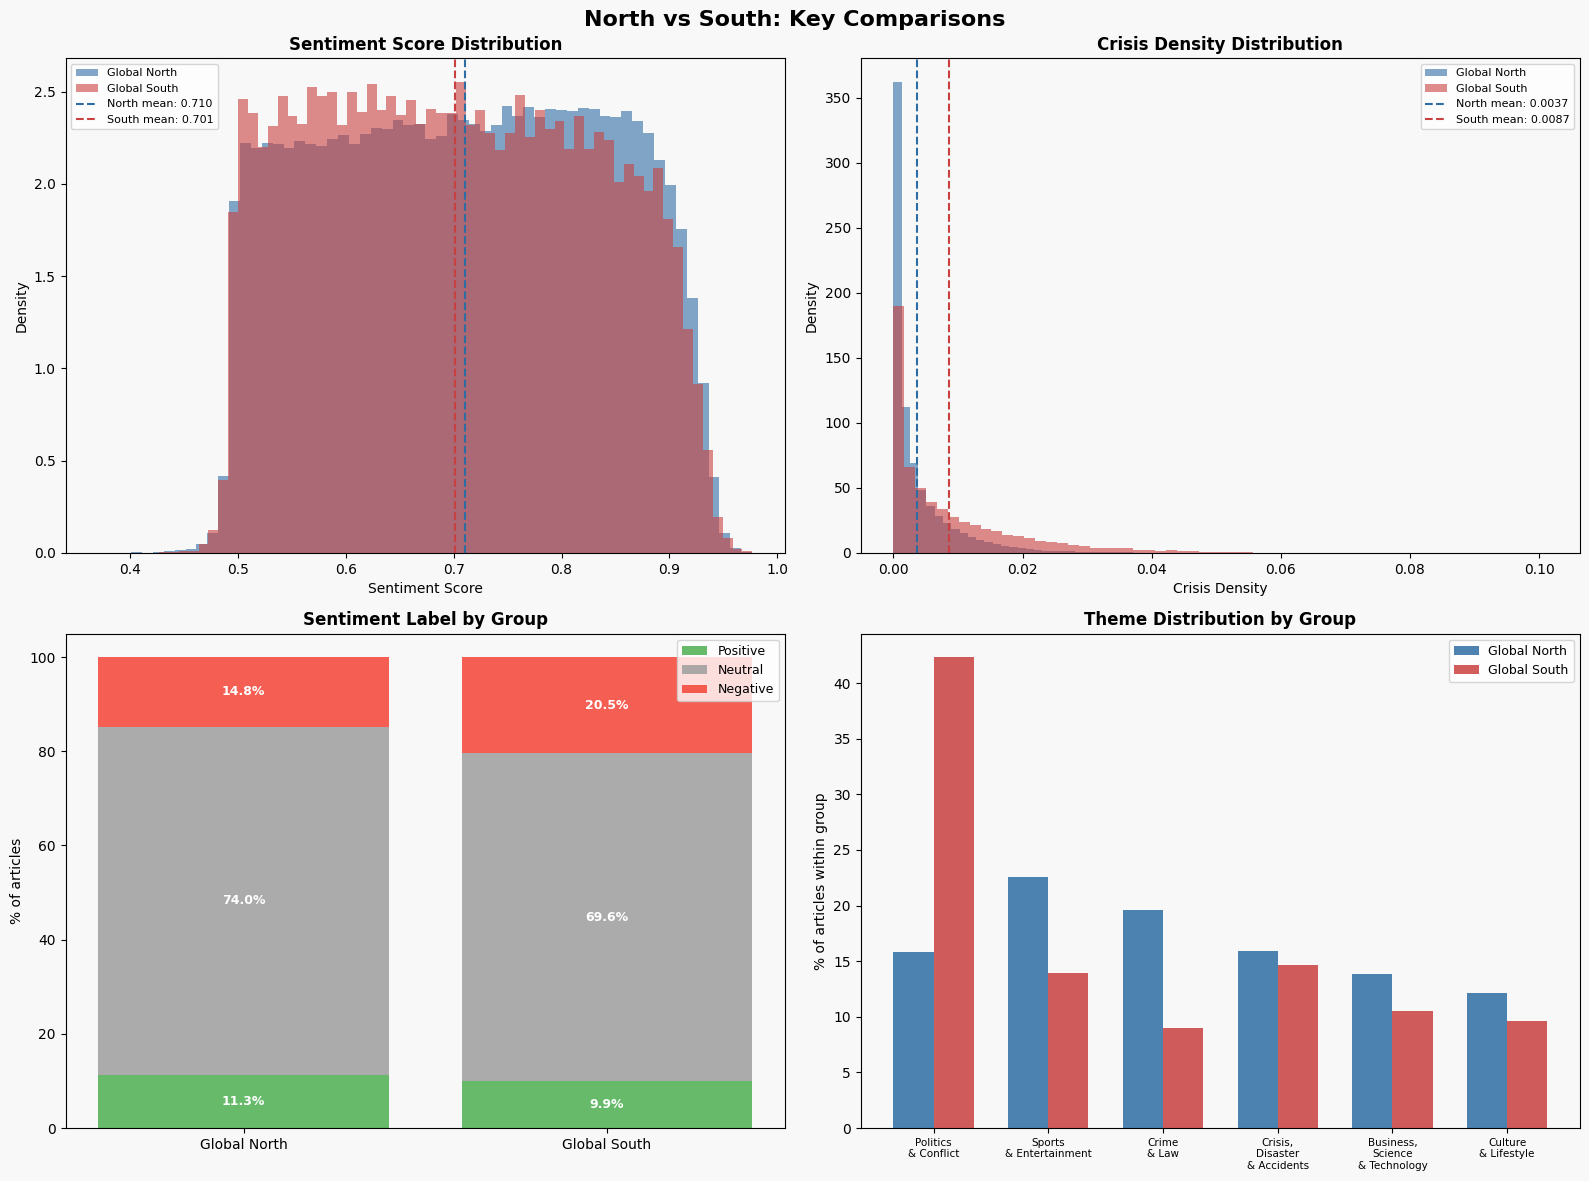

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor="#F8F8F8")
fig.suptitle("North vs South: Key Comparisons", fontsize=16, fontweight="bold")

NORTH_COL = "#2E6DA4"
SOUTH_COL = "#C94040"
north = df[df["global_north_or_south"] == "Global North"]
south = df[df["global_north_or_south"] == "Global South"]

# ── Sentiment score distribution ──────────────────────────────────────────────
ax1 = axes[0, 0]
ax1.hist(north["sentiment_score"].dropna(), bins=60, alpha=0.6, color=NORTH_COL, density=True, label="Global North")
ax1.hist(south["sentiment_score"].dropna(), bins=60, alpha=0.6, color=SOUTH_COL, density=True, label="Global South")
ax1.axvline(north["sentiment_score"].mean(), color=NORTH_COL, linestyle="--", linewidth=1.5, label=f"North mean: {north['sentiment_score'].mean():.3f}")
ax1.axvline(south["sentiment_score"].mean(), color=SOUTH_COL, linestyle="--", linewidth=1.5, label=f"South mean: {south['sentiment_score'].mean():.3f}")
ax1.set_title("Sentiment Score Distribution", fontweight="bold")
ax1.set_xlabel("Sentiment Score")
ax1.set_ylabel("Density")
ax1.legend(fontsize=8)
ax1.set_facecolor("#F8F8F8")

# ── Crisis density distribution ───────────────────────────────────────────────
ax2 = axes[0, 1]
ax2.hist(north["crisis_density"].dropna(), bins=60, alpha=0.6, color=NORTH_COL, density=True, label="Global North")
ax2.hist(south["crisis_density"].dropna(), bins=60, alpha=0.6, color=SOUTH_COL, density=True, label="Global South")
ax2.axvline(north["crisis_density"].mean(), color=NORTH_COL, linestyle="--", linewidth=1.5, label=f"North mean: {north['crisis_density'].mean():.4f}")
ax2.axvline(south["crisis_density"].mean(), color=SOUTH_COL, linestyle="--", linewidth=1.5, label=f"South mean: {south['crisis_density'].mean():.4f}")
ax2.set_title("Crisis Density Distribution", fontweight="bold")
ax2.set_xlabel("Crisis Density")
ax2.set_ylabel("Density")
ax2.legend(fontsize=8)
ax2.set_facecolor("#F8F8F8")

# ── Sentiment label by group (stacked %) ─────────────────────────────────────
ax3 = axes[1, 0]
sent_colors = {"positive": "#4CAF50", "neutral": "#9E9E9E", "negative": "#F44336"}
groups = ["Global North", "Global South"]
bottom = np.zeros(2)
for sent in ["positive", "neutral", "negative"]:
    vals = [
        north["sentiment_label"].value_counts(normalize=True).get(sent, 0) * 100,
        south["sentiment_label"].value_counts(normalize=True).get(sent, 0) * 100
    ]
    bars = ax3.bar(groups, vals, bottom=bottom, color=sent_colors[sent], label=sent.capitalize(), alpha=0.85)
    for bar, val, bot in zip(bars, vals, bottom):
        if val > 3:
            ax3.text(bar.get_x() + bar.get_width()/2, bot + val/2,
                    f"{val:.1f}%", ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    bottom += np.array(vals)
ax3.set_title("Sentiment Label by Group", fontweight="bold")
ax3.set_ylabel("% of articles")
ax3.legend(fontsize=9)
ax3.set_facecolor("#F8F8F8")

# ── Theme by group (% within group) ──────────────────────────────────────────
ax4 = axes[1, 1]
themes = df["theme"].value_counts().index.tolist()
w = 0.35
x = np.arange(len(themes))
n_theme = [north["theme"].value_counts(normalize=True).get(t, 0) * 100 for t in themes]
s_theme = [south["theme"].value_counts(normalize=True).get(t, 0) * 100 for t in themes]
ax4.bar(x - w/2, n_theme, w, color=NORTH_COL, alpha=0.85, label="Global North")
ax4.bar(x + w/2, s_theme, w, color=SOUTH_COL, alpha=0.85, label="Global South")
ax4.set_xticks(x)
ax4.set_xticklabels([t.replace(" & ", "\n& ").replace(", ", ",\n") for t in themes], fontsize=7.5)
ax4.set_ylabel("% of articles within group")
ax4.set_title("Theme Distribution by Group", fontweight="bold")
ax4.legend(fontsize=9)
ax4.set_facecolor("#F8F8F8")

plt.tight_layout()
plt.show()

Sentiment score: the distributions overlap heavily but South has a slightly lower mean (0.701 vs 0.710) and a fatter left tail, meaning more low-sentiment articles. 


Crisis density: South mean is more than double North (0.0087 vs 0.0037), and the South distribution has a much heavier right tail. This strongly suggests Global South countries are framed with significantly more crisis language.


Sentiment labels: South has notably more negative articles (20.5% vs 14.8%) and fewer neutral ones. That's a meaningful difference.


Theme distribution: the biggest gap is in Politics & Conflict where South is dramatically overrepresented (~42% vs ~16%), and Sports & Entertainment where North dominates (~23% vs ~14%).

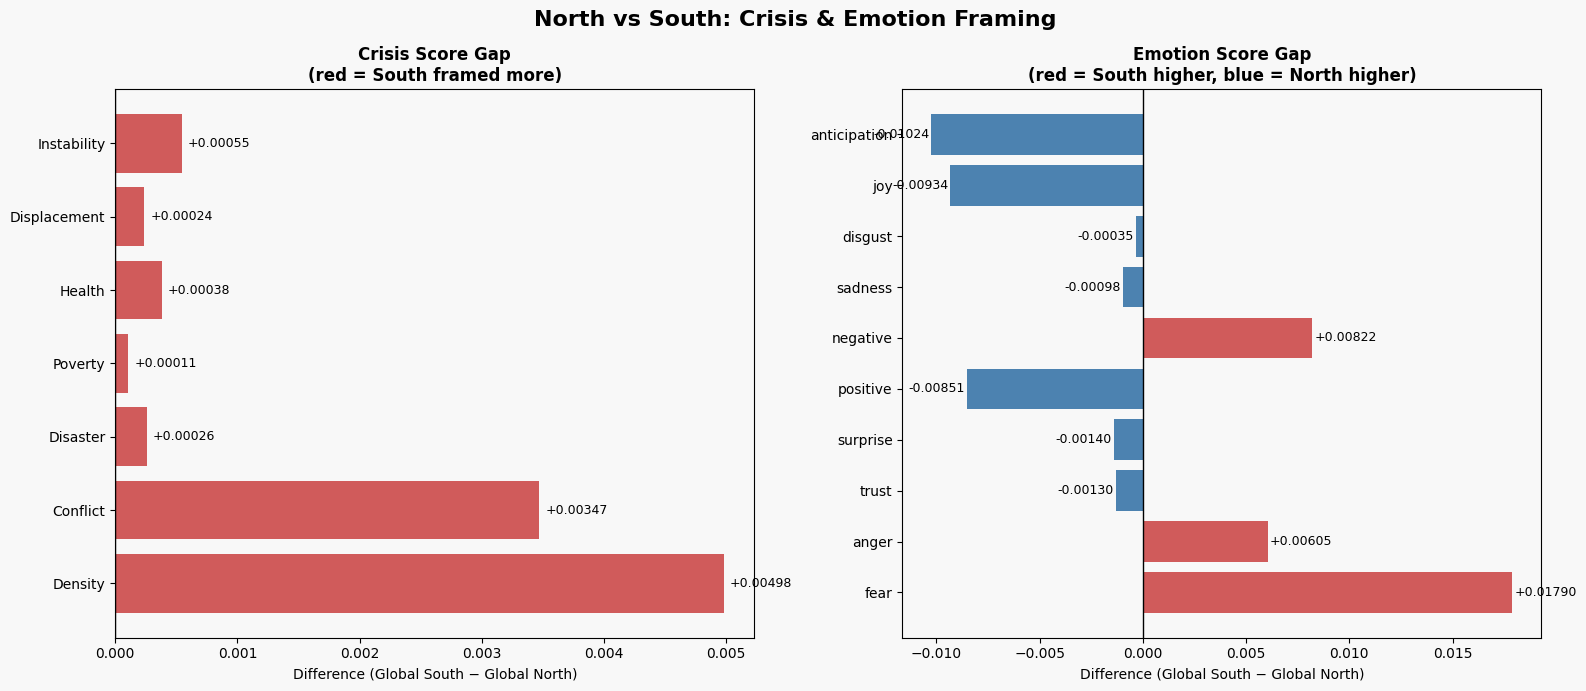

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor="#F8F8F8")
fig.suptitle("North vs South: Crisis & Emotion Framing", fontsize=16, fontweight="bold")

NORTH_COL = "#2E6DA4"
SOUTH_COL = "#C94040"

# ── Crisis scores gap ─────────────────────────────────────────────────────────
ax1 = axes[0]
crisis_cols = ["crisis_density", "crisis_conflict", "crisis_disaster",
               "crisis_poverty", "crisis_health", "crisis_displacement", "crisis_instability"]
crisis_labels = ["Density", "Conflict", "Disaster", "Poverty", "Health", "Displacement", "Instability"]

diffs_crisis = [south[c].mean() - north[c].mean() for c in crisis_cols]
colors = [SOUTH_COL if d > 0 else NORTH_COL for d in diffs_crisis]
bars = ax1.barh(crisis_labels, diffs_crisis, color=colors, alpha=0.85)
ax1.axvline(0, color="black", linewidth=1)
ax1.set_xlabel("Difference (Global South − Global North)")
ax1.set_title("Crisis Score Gap\n(red = South framed more)", fontweight="bold")
ax1.set_facecolor("#F8F8F8")
for bar, d in zip(bars, diffs_crisis):
    ax1.text(d + (0.00005 if d >= 0 else -0.00005), bar.get_y() + bar.get_height()/2,
             f"{d:+.5f}", va="center", ha="left" if d >= 0 else "right", fontsize=9)

# ── Emotion scores gap ────────────────────────────────────────────────────────
ax2 = axes[1]
emotion_cols = ["fear", "anger", "trust", "surprise",
                "positive", "negative", "sadness", "disgust", "joy", "anticipation"]
diffs_emotion = [south[c].mean() - north[c].mean() for c in emotion_cols]
colors_e = [SOUTH_COL if d > 0 else NORTH_COL for d in diffs_emotion]
bars2 = ax2.barh(emotion_cols, diffs_emotion, color=colors_e, alpha=0.85)
ax2.axvline(0, color="black", linewidth=1)
ax2.set_xlabel("Difference (Global South − Global North)")
ax2.set_title("Emotion Score Gap\n(red = South higher, blue = North higher)", fontweight="bold")
ax2.set_facecolor("#F8F8F8")
for bar, d in zip(bars2, diffs_emotion):
    ax2.text(d + (0.0001 if d >= 0 else -0.0001), bar.get_y() + bar.get_height()/2,
             f"{d:+.5f}", va="center", ha="left" if d >= 0 else "right", fontsize=9)

plt.tight_layout()
plt.show()

Crisis: every single crisis type is higher for the South, with conflict and density being the biggest gaps.

Emotions: South articles have substantially more fear (+0.0179) and anger (+0.0061) and more negative framing (+0.0082), while North articles score higher on positive (+0.0085), joy (+0.0093) and anticipation (+0.0102). Trust and surprise also lean slightly North.

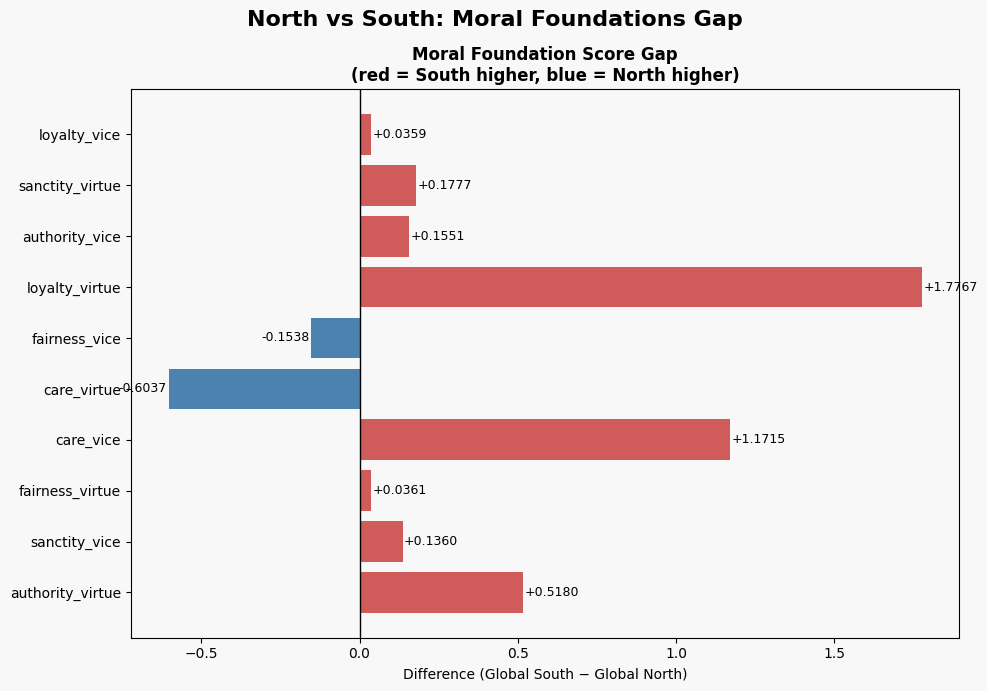

In [12]:
fig, ax = plt.subplots(figsize=(10, 7), facecolor="#F8F8F8")
fig.suptitle("North vs South: Moral Foundations Gap", fontsize=16, fontweight="bold")

NORTH_COL = "#2E6DA4"
SOUTH_COL = "#C94040"

moral_cols = ["authority_virtue", "sanctity_vice", "fairness_virtue", "care_vice",
              "care_virtue", "fairness_vice", "loyalty_virtue", "authority_vice",
              "sanctity_virtue", "loyalty_vice"]

diffs_moral = [south[c].mean() - north[c].mean() for c in moral_cols]
colors_m = [SOUTH_COL if d > 0 else NORTH_COL for d in diffs_moral]
bars = ax.barh(moral_cols, diffs_moral, color=colors_m, alpha=0.85)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Difference (Global South − Global North)")
ax.set_title("Moral Foundation Score Gap\n(red = South higher, blue = North higher)", fontweight="bold")
ax.set_facecolor("#F8F8F8")
for bar, d in zip(bars, diffs_moral):
    ax.text(d + (0.005 if d >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f"{d:+.4f}", va="center", ha="left" if d >= 0 else "right", fontsize=9)

plt.tight_layout()
plt.show()

South higher: loyalty_virtue is the biggest gap (+1.78), followed by care_vice (+1.17) and authority_virtue (+0.52). This suggests South country coverage invokes more loyalty and authority language, and more care-related negative framing.

North higher: care_virtue (-0.60) is the biggest gap in the other direction, meaning North coverage uses more positive care language. fairness_vice is also slightly higher for North (-0.15).

The pattern is less clean than crisis and emotions. It suggests moral framing is more complex than simple positive/negative framing.

### HDI visualisations

In [13]:
# ── Aggregate to country level ────────────────────────────────────────────────
continuous_media = [
    "sentiment_polarity", "crisis_density", "crisis_conflict", "crisis_disaster",
    "crisis_poverty", "crisis_health", "crisis_displacement", "crisis_instability",
    "fear", "anger", "trust", "surprise", "positive", "negative",
    "sadness", "disgust", "joy", "anticipation"
]

country_df = df.groupby("country")[continuous_media + ["hdi", "trade_value"]].mean().reset_index()
print(f"  Countries: {len(country_df)}")
print(f"  HDI range: {country_df['hdi'].min():.3f} — {country_df['hdi'].max():.3f}")
print(country_df[["country", "hdi", "trade_value", "sentiment_polarity", "crisis_density"]].sort_values("hdi").to_string())

  Countries: 163
  HDI range: 0.374 — 0.959
                              country    hdi   trade_value  sentiment_polarity  crisis_density
107                             Niger  0.374  7.897703e+08           -0.112311        0.014817
31           Central African Republic  0.377  9.685368e+07           -0.136904        0.012950
25                       Burkina Faso  0.419  2.216983e+09           -0.036694        0.012140
26                            Burundi  0.432  1.137907e+08           -0.309579        0.015075
134                      Sierra Leone  0.432  9.325755e+07           -0.120730        0.025946
47                           Ethiopia  0.456  2.023552e+09            0.048751        0.004501
100                        Mozambique  0.457  3.230744e+09           -0.023227        0.008065
58                             Guinea  0.465  1.573675e+09           -0.189289        0.029992
160                             Yemen  0.475  5.098577e+08           -0.238919        0.018640
40    

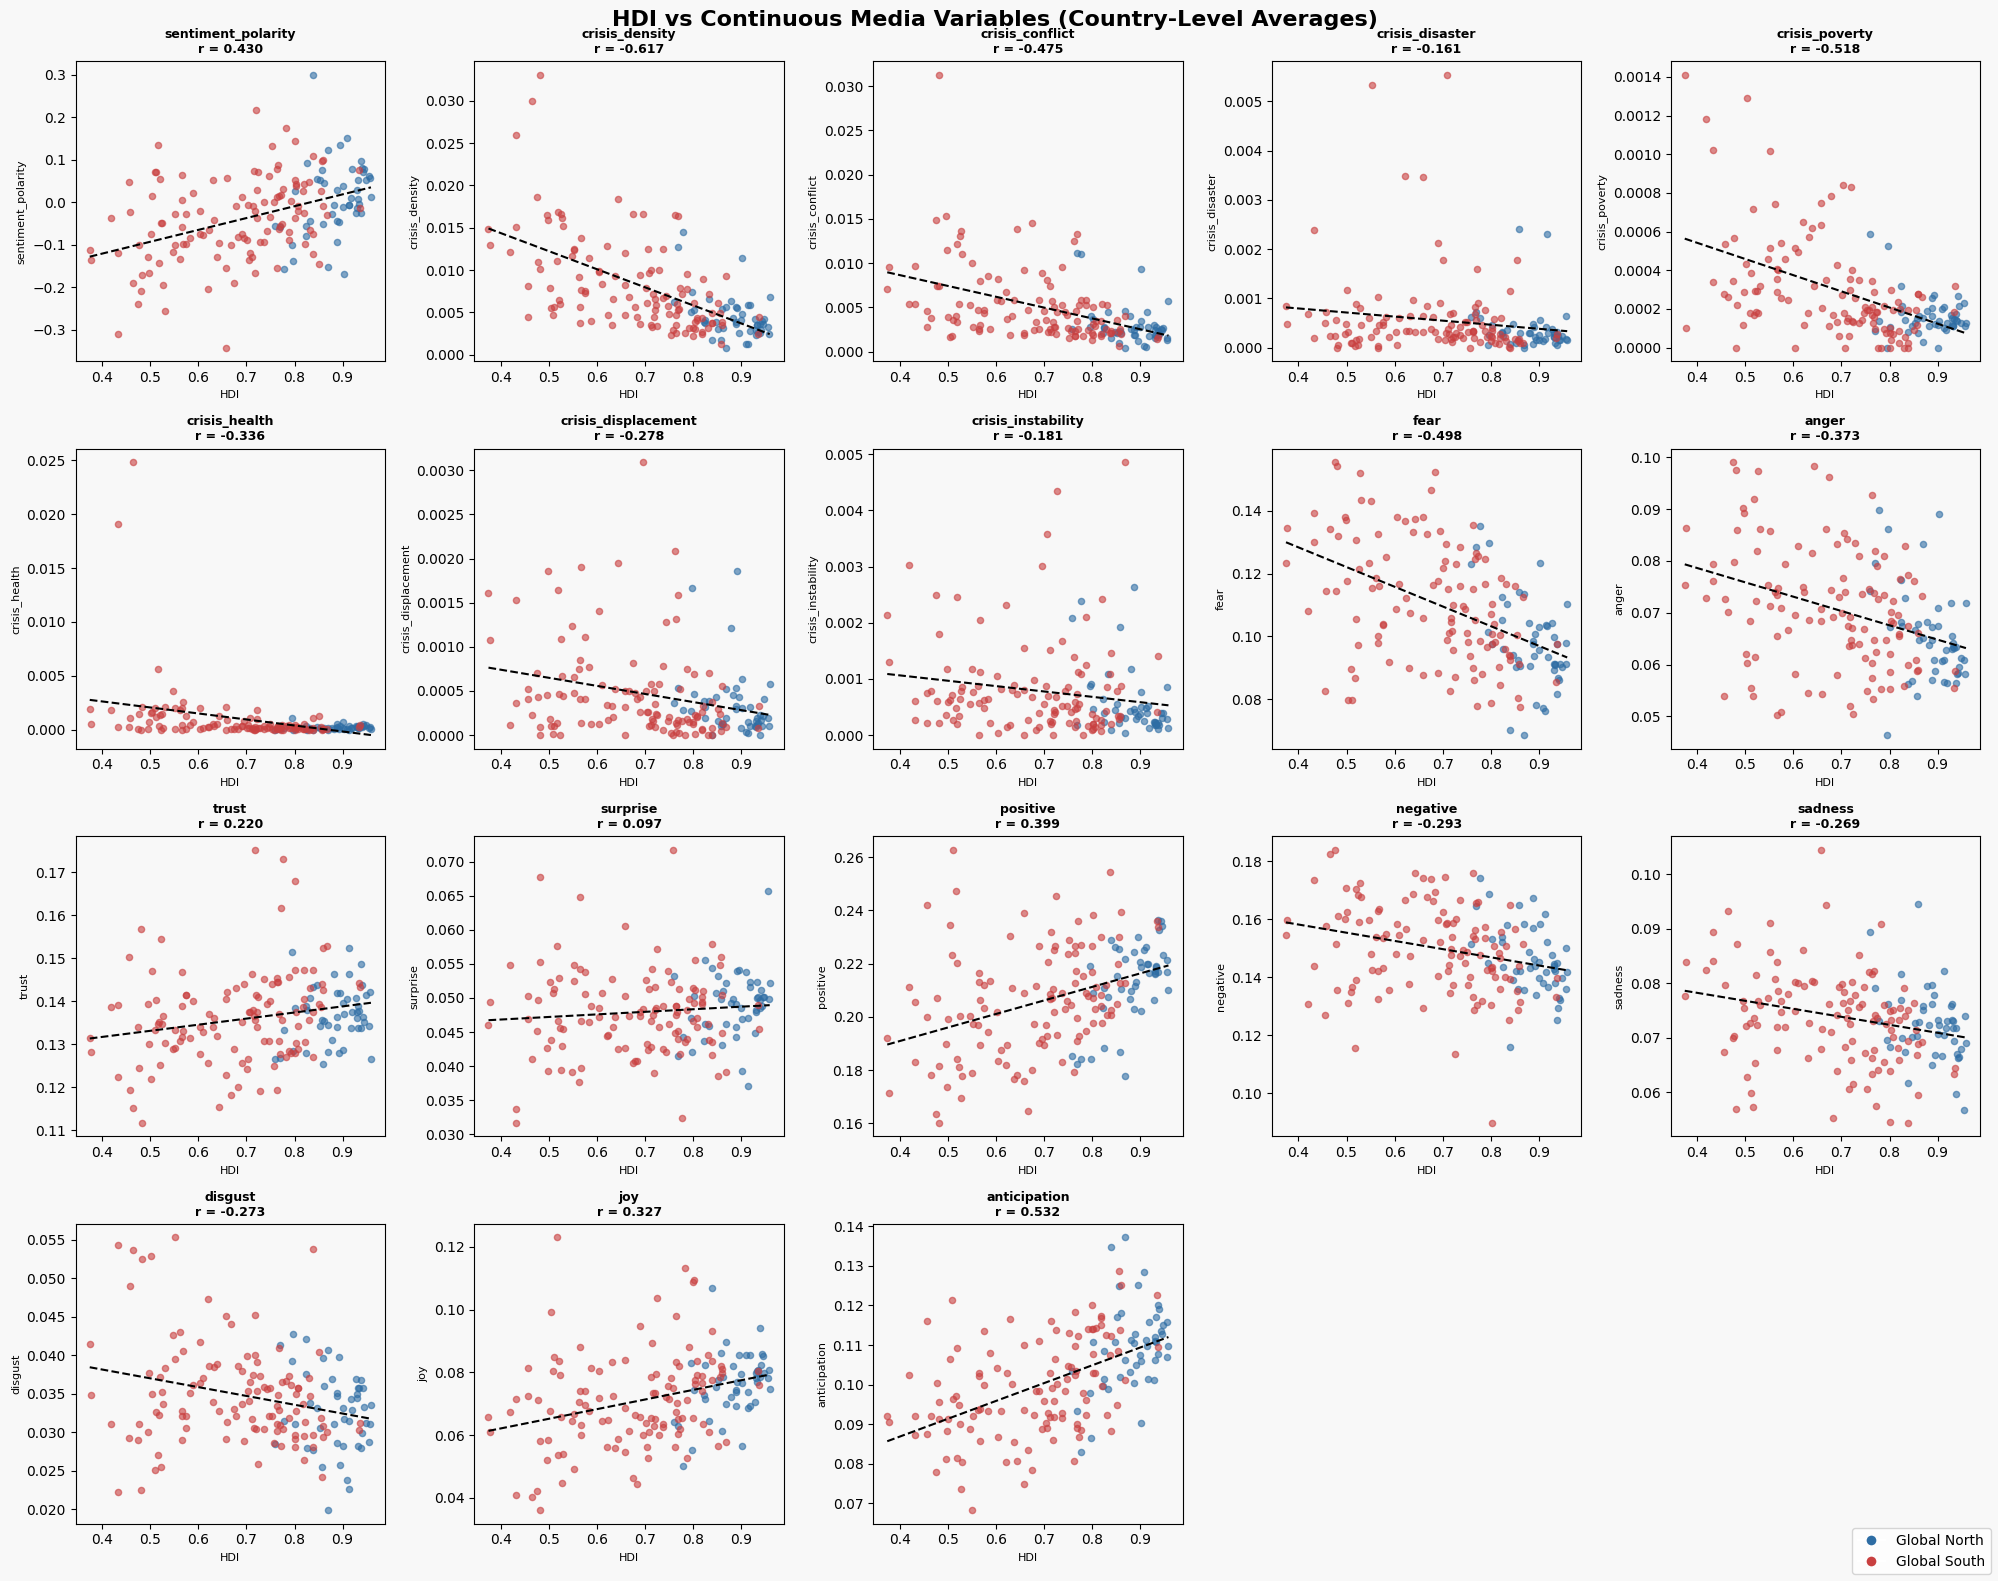

In [14]:
fig, axes = plt.subplots(4, 5, figsize=(20, 16), facecolor="#F8F8F8")
fig.suptitle("HDI vs Continuous Media Variables (Country-Level Averages)", fontsize=16, fontweight="bold")
axes = axes.flatten()

NORTH_COL = "#2E6DA4"
SOUTH_COL = "#C94040"

for i, col in enumerate(continuous_media):
    ax = axes[i]
    
    # color points by North/South
    for grp, color, label in [("Global North", NORTH_COL, "Global North"), 
                                ("Global South", SOUTH_COL, "Global South")]:
        mask = df.groupby("country")["global_north_or_south"].first() == grp
        sub = country_df[country_df["country"].isin(mask[mask].index)]
        ax.scatter(sub["hdi"], sub[col], color=color, alpha=0.6, s=20, label=label)
    
    # trend line
    mask = country_df[["hdi", col]].dropna()
    z = np.polyfit(mask["hdi"], mask[col], 1)
    p = np.poly1d(z)
    x_line = np.linspace(mask["hdi"].min(), mask["hdi"].max(), 100)
    ax.plot(x_line, p(x_line), color="black", linewidth=1.5, linestyle="--")
    corr = mask["hdi"].corr(mask[col])
    ax.set_title(f"{col}\nr = {corr:.3f}", fontsize=9, fontweight="bold")
    ax.set_xlabel("HDI", fontsize=8)
    ax.set_ylabel(col, fontsize=8)
    ax.set_facecolor("#F8F8F8")

# hide unused subplots
for j in range(len(continuous_media), len(axes)):
    axes[j].set_visible(False)

# legend
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=NORTH_COL, markersize=8, label="Global North"),
           plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=SOUTH_COL, markersize=8, label="Global South")]
fig.legend(handles=handles, loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()

Strongest negative correlations with HDI (lower HDI = more of this in coverage):

crisis_density (r = -0.617) 
crisis_conflict (r = -0.475)
crisis_poverty (r = -0.518)
fear (r = -0.498)
anger (r = -0.373)

Strongest positive correlations with HDI (higher HDI = more of this):

anticipation (r = 0.532)
positive (r = 0.399)
joy (r = 0.327)
trust (r = 0.220)

['country', 'sentiment_polarity', 'crisis_density', 'crisis_conflict', 'crisis_disaster', 'crisis_poverty', 'crisis_health', 'crisis_displacement', 'crisis_instability', 'fear', 'anger', 'trust', 'surprise', 'positive', 'negative', 'sadness', 'disgust', 'joy', 'anticipation', 'hdi', 'trade_value', 'global_north_or_south']


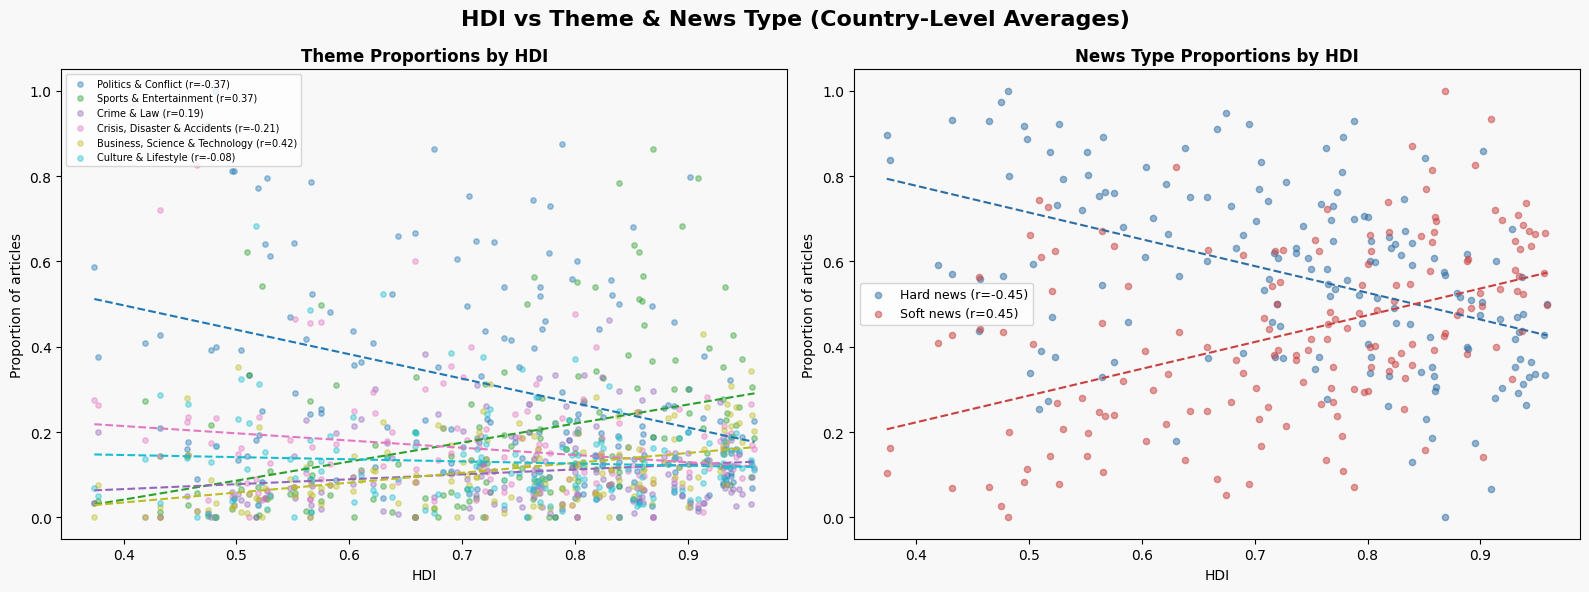

In [15]:
# add global_north_or_south to country_df
country_meta = df.groupby("country")["global_north_or_south"].first().reset_index()
country_df = country_df.merge(country_meta, on="country")
print(country_df.columns.tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor="#F8F8F8")
fig.suptitle("HDI vs Theme & News Type (Country-Level Averages)", fontsize=16, fontweight="bold")

NORTH_COL = "#2E6DA4"
SOUTH_COL = "#C94040"

# ── get country-level proportions ─────────────────────────────────────────────
country_theme = df.groupby("country").apply(
    lambda x: x["theme"].value_counts(normalize=True)
).unstack(fill_value=0).reset_index()
country_theme = country_theme.merge(country_df[["country", "hdi", "global_north_or_south"]], on="country")

country_news = df.groupby("country").apply(
    lambda x: x["news_type"].value_counts(normalize=True)
).unstack(fill_value=0).reset_index()
country_news = country_news.merge(country_df[["country", "hdi", "global_north_or_south"]], on="country")

# ── HDI vs theme proportions ──────────────────────────────────────────────────
ax1 = axes[0]
themes = df["theme"].value_counts().index.tolist()
theme_colors = plt.cm.tab10(np.linspace(0, 1, len(themes)))
for theme, color in zip(themes, theme_colors):
    if theme in country_theme.columns:
        corr = country_theme["hdi"].corr(country_theme[theme])
        ax1.scatter(country_theme["hdi"], country_theme[theme],
                   alpha=0.4, s=15, color=color, label=f"{theme} (r={corr:.2f})")
        z = np.polyfit(country_theme["hdi"], country_theme[theme], 1)
        p = np.poly1d(z)
        x_line = np.linspace(country_theme["hdi"].min(), country_theme["hdi"].max(), 100)
        ax1.plot(x_line, p(x_line), color=color, linewidth=1.5, linestyle="--")
ax1.set_xlabel("HDI")
ax1.set_ylabel("Proportion of articles")
ax1.set_title("Theme Proportions by HDI", fontweight="bold")
ax1.legend(fontsize=7, loc="upper left")
ax1.set_facecolor("#F8F8F8")

# ── HDI vs news type proportions ──────────────────────────────────────────────
ax2 = axes[1]
for news_type, color in zip(["Hard news", "Soft news"], [NORTH_COL, SOUTH_COL]):
    if news_type in country_news.columns:
        corr = country_news["hdi"].corr(country_news[news_type])
        ax2.scatter(country_news["hdi"], country_news[news_type],
                   alpha=0.5, s=20, color=color, label=f"{news_type} (r={corr:.2f})")
        z = np.polyfit(country_news["hdi"], country_news[news_type], 1)
        p = np.poly1d(z)
        x_line = np.linspace(country_news["hdi"].min(), country_news["hdi"].max(), 100)
        ax2.plot(x_line, p(x_line), color=color, linewidth=1.5, linestyle="--")
ax2.set_xlabel("HDI")
ax2.set_ylabel("Proportion of articles")
ax2.set_title("News Type Proportions by HDI", fontweight="bold")
ax2.legend(fontsize=9)
ax2.set_facecolor("#F8F8F8")

plt.tight_layout()
plt.show()

Themes: Politics & Conflict decreases strongly with HDI (r = -0.37), meaning lower HDI countries get covered predominantly through a conflict lens. Business, Science & Technology (r = 0.42) and Sports & Entertainment (r = 0.37) increase with HDI, so higher HDI countries get more of those softer, more varied themes.


News type: this is a strong and clean result. Hard news dominates low HDI country coverage (r = -0.45) while soft news increases with HDI (r = 0.45). The two lines cross around HDI 0.85, meaning below that threshold countries are predominantly covered through hard news.

### Trade value visualisations

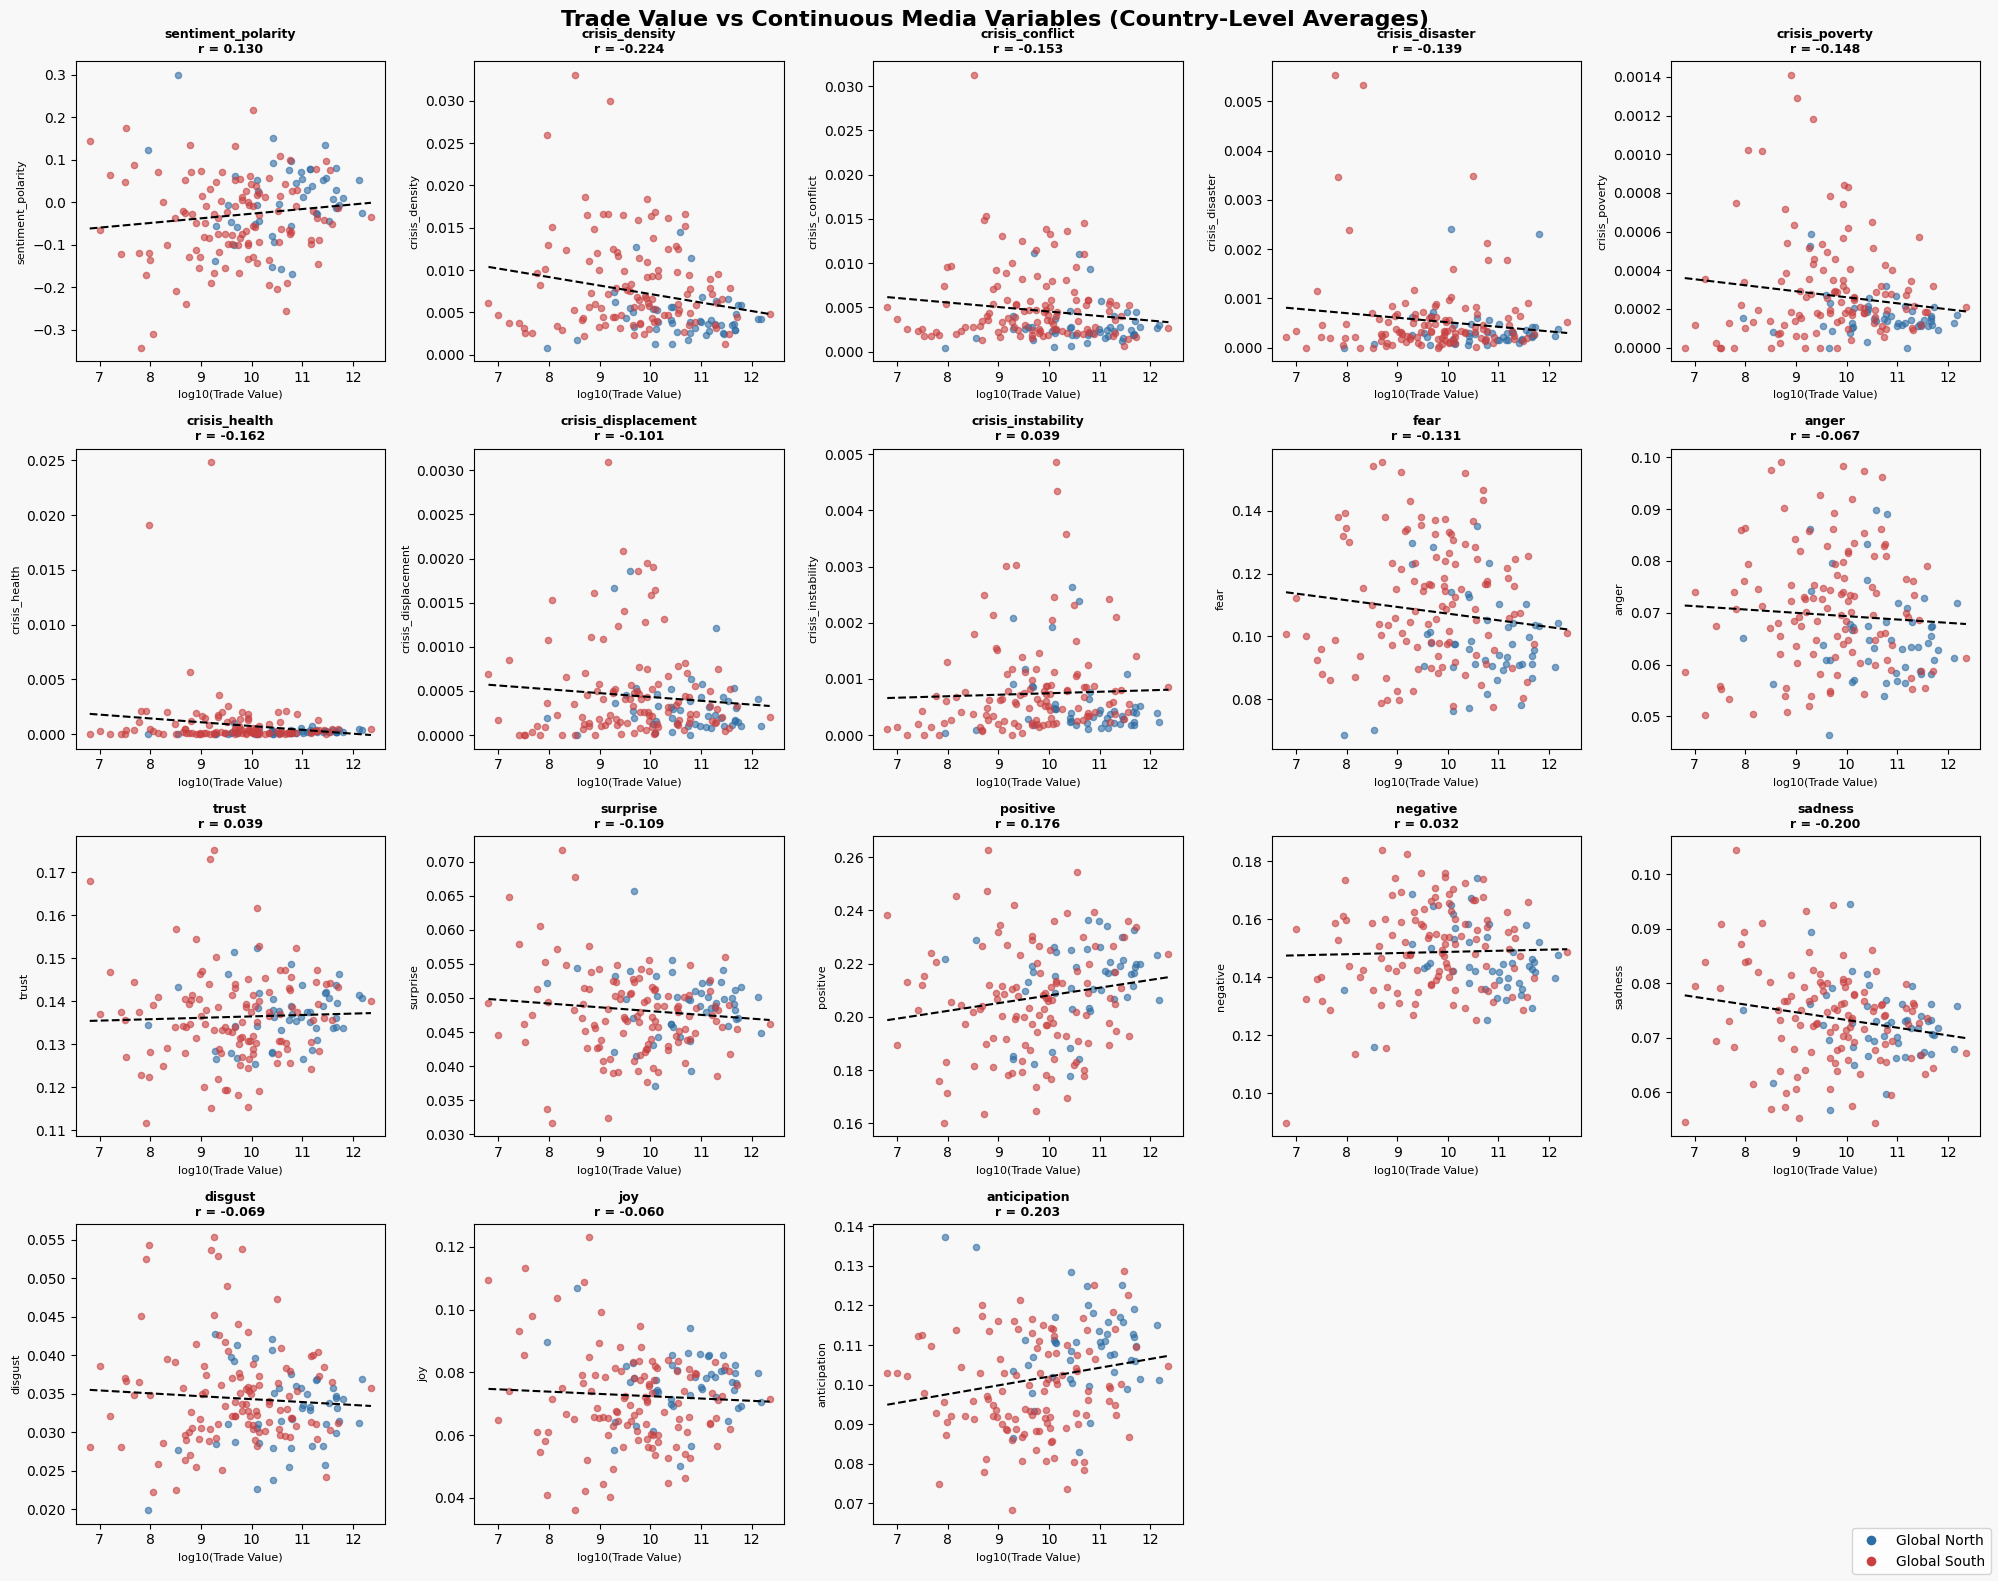

In [16]:
fig, axes = plt.subplots(4, 5, figsize=(20, 16), facecolor="#F8F8F8")
fig.suptitle("Trade Value vs Continuous Media Variables (Country-Level Averages)", fontsize=16, fontweight="bold")
axes = axes.flatten()

NORTH_COL = "#2E6DA4"
SOUTH_COL = "#C94040"

continuous_media = [
    "sentiment_polarity", "crisis_density", "crisis_conflict", "crisis_disaster",
    "crisis_poverty", "crisis_health", "crisis_displacement", "crisis_instability",
    "fear", "anger", "trust", "surprise", "positive", "negative",
    "sadness", "disgust", "joy", "anticipation"
]

for i, col in enumerate(continuous_media):
    ax = axes[i]
    
    for grp, color in [("Global North", NORTH_COL), ("Global South", SOUTH_COL)]:
        mask = country_df["global_north_or_south"] == grp
        sub = country_df[mask]
        ax.scatter(np.log10(sub["trade_value"]), sub[col], color=color, alpha=0.6, s=20)
    
    # trend line
    valid = country_df[["trade_value", col]].dropna()
    log_trade = np.log10(valid["trade_value"])
    z = np.polyfit(log_trade, valid[col], 1)
    p = np.poly1d(z)
    x_line = np.linspace(log_trade.min(), log_trade.max(), 100)
    ax.plot(x_line, p(x_line), color="black", linewidth=1.5, linestyle="--")
    corr = log_trade.corr(valid[col])
    ax.set_title(f"{col}\nr = {corr:.3f}", fontsize=9, fontweight="bold")
    ax.set_xlabel("log10(Trade Value)", fontsize=8)
    ax.set_ylabel(col, fontsize=8)
    ax.set_facecolor("#F8F8F8")

for j in range(len(continuous_media), len(axes)):
    axes[j].set_visible(False)

handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=NORTH_COL, markersize=8, label="Global North"),
           plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=SOUTH_COL, markersize=8, label="Global South")]
fig.legend(handles=handles, loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()

Weakest predictor overall: most correlations are below 0.2, compared to HDI where we had several above 0.4 and 0.5. Trade value is clearly less informative than HDI for predicting media representation.

Same direction but weaker: crisis_density (r = -0.224), fear (r = -0.131), sadness (r = -0.200) all go in the expected direction but weakly. Higher trade value countries get slightly less crisis and fear coverage.

More mixing of North and South: unlike HDI where the groups were cleanly separated, here you can see red and blue dots are much more interleaved, especially in the middle range. Some Global South countries have high trade values (China, Brazil, India) which disrupts the pattern.

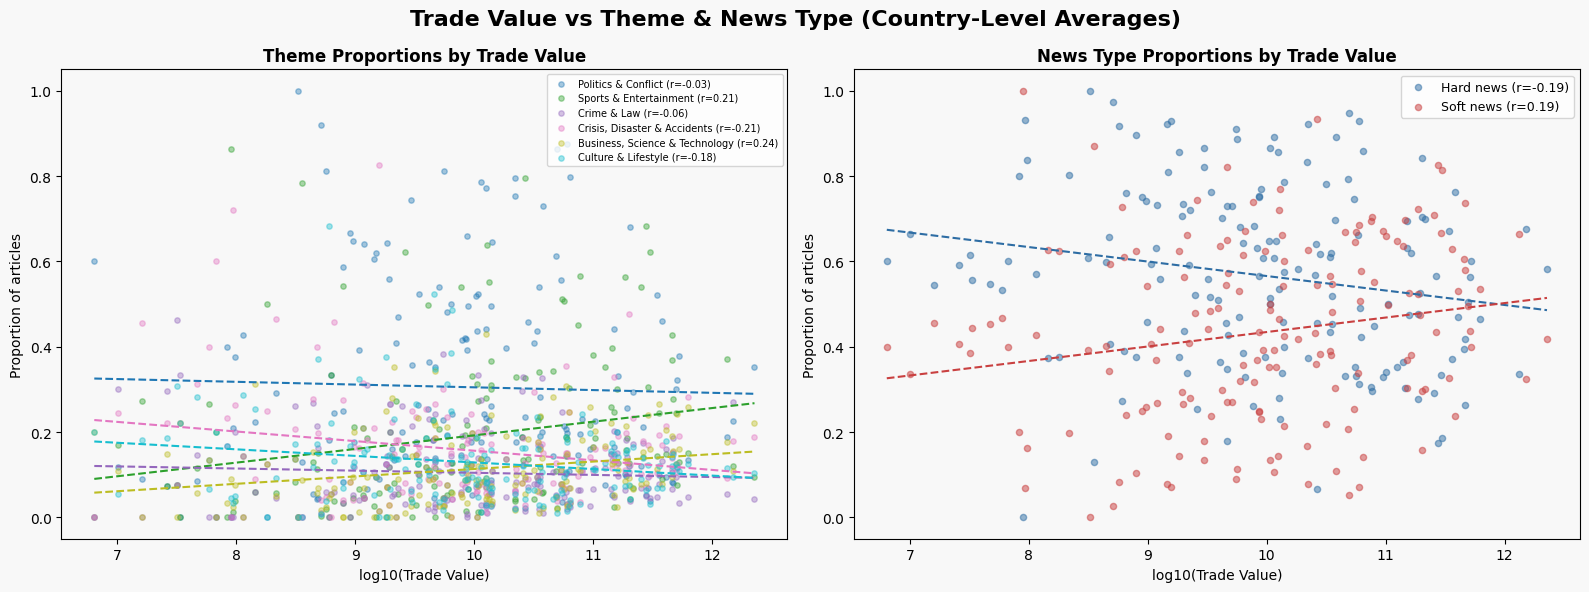

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor="#F8F8F8")
fig.suptitle("Trade Value vs Theme & News Type (Country-Level Averages)", fontsize=16, fontweight="bold")

NORTH_COL = "#2E6DA4"
SOUTH_COL = "#C94040"

country_theme = df.groupby("country").apply(
    lambda x: x["theme"].value_counts(normalize=True)
).unstack(fill_value=0).reset_index()
country_theme = country_theme.merge(country_df[["country", "trade_value", "global_north_or_south"]], on="country")

country_news = df.groupby("country").apply(
    lambda x: x["news_type"].value_counts(normalize=True)
).unstack(fill_value=0).reset_index()
country_news = country_news.merge(country_df[["country", "trade_value", "global_north_or_south"]], on="country")

# ── Trade value vs theme proportions ─────────────────────────────────────────
ax1 = axes[0]
themes = df["theme"].value_counts().index.tolist()
theme_colors = plt.cm.tab10(np.linspace(0, 1, len(themes)))
for theme, color in zip(themes, theme_colors):
    if theme in country_theme.columns:
        log_trade = np.log10(country_theme["trade_value"])
        corr = log_trade.corr(country_theme[theme])
        ax1.scatter(log_trade, country_theme[theme],
                   alpha=0.4, s=15, color=color, label=f"{theme} (r={corr:.2f})")
        z = np.polyfit(log_trade, country_theme[theme], 1)
        p = np.poly1d(z)
        x_line = np.linspace(log_trade.min(), log_trade.max(), 100)
        ax1.plot(x_line, p(x_line), color=color, linewidth=1.5, linestyle="--")
ax1.set_xlabel("log10(Trade Value)")
ax1.set_ylabel("Proportion of articles")
ax1.set_title("Theme Proportions by Trade Value", fontweight="bold")
ax1.legend(fontsize=7, loc="upper right")
ax1.set_facecolor("#F8F8F8")

# ── Trade value vs news type proportions ──────────────────────────────────────
ax2 = axes[1]
for news_type, color in zip(["Hard news", "Soft news"], [NORTH_COL, SOUTH_COL]):
    if news_type in country_news.columns:
        log_trade = np.log10(country_news["trade_value"])
        corr = log_trade.corr(country_news[news_type])
        ax2.scatter(log_trade, country_news[news_type],
                   alpha=0.5, s=20, color=color, label=f"{news_type} (r={corr:.2f})")
        z = np.polyfit(log_trade, country_news[news_type], 1)
        p = np.poly1d(z)
        x_line = np.linspace(log_trade.min(), log_trade.max(), 100)
        ax2.plot(x_line, p(x_line), color=color, linewidth=1.5, linestyle="--")
ax2.set_xlabel("log10(Trade Value)")
ax2.set_ylabel("Proportion of articles")
ax2.set_title("News Type Proportions by Trade Value", fontweight="bold")
ax2.legend(fontsize=9)
ax2.set_facecolor("#F8F8F8")

plt.tight_layout()
plt.show()

The correlations are all below 0.25 and the scatter is very wide. The directions are consistent: Politics & Conflict slightly decreases with trade value, Business & Science slightly increases, but nothing strong enough to be very meaningful.

The news type plot shows the same pattern as HDI with hard news decreasing and soft news increasing with trade value (r = ±0.19), but again much weaker than the HDI equivalent (r = ±0.45).
HDI is the more meaningful structural predictor. Trade value adds some information but is clearly secondary.

### Correlation grid

<function matplotlib.pyplot.show(close=None, block=None)>

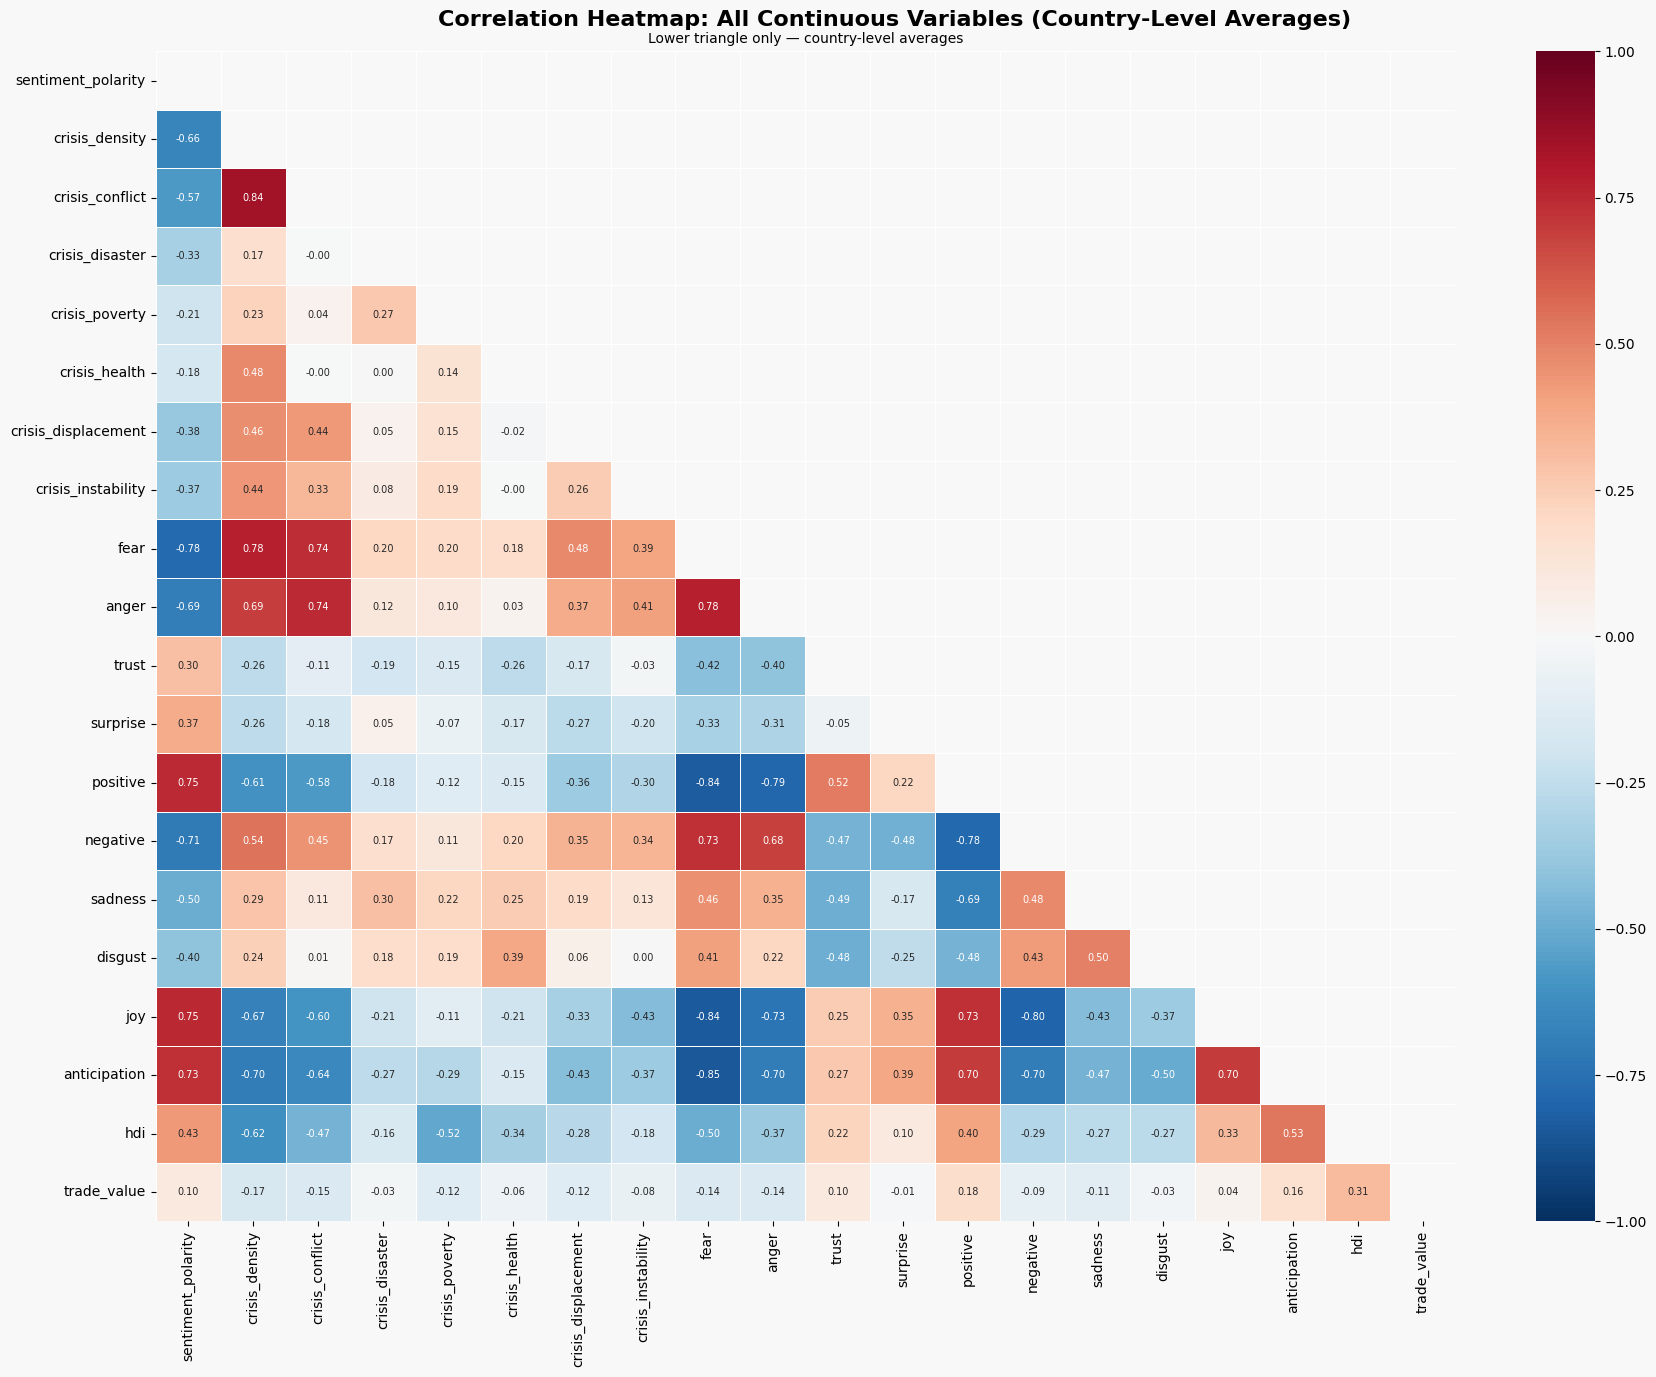

In [18]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(18, 14), facecolor="#F8F8F8")
fig.suptitle("Correlation Heatmap: All Continuous Variables (Country-Level Averages)", 
             fontsize=16, fontweight="bold")

continuous_media = [
    "sentiment_polarity", "crisis_density", "crisis_conflict", "crisis_disaster",
    "crisis_poverty", "crisis_health", "crisis_displacement", "crisis_instability",
    "fear", "anger", "trust", "surprise", "positive", "negative",
    "sadness", "disgust", "joy", "anticipation"
]

corr_cols = continuous_media + ["hdi", "trade_value"]
corr_matrix = country_df[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={"size": 7}, linewidths=0.5)
ax.set_title("Lower triangle only — country-level averages", fontsize=10)
ax.set_facecolor("#F8F8F8")
plt.tight_layout()
plt.show

Very high correlations between some predictors:

fear & anger (r = 0.78)
fear & crisis_density (r = 0.78), fear & crisis_conflict (r = 0.74)
positive & negative (r = -0.78)
joy & fear (r = -0.84), joy & anticipation (r = 0.70)
anticipation & fear (r = -0.85)
crisis_density & crisis_conflict (r = 0.84)

HDI correlations: confirms what we saw in the scatter plots. Strongest with crisis_density (-0.62), crisis_conflict (-0.47), crisis_poverty (-0.52), fear (-0.50), anticipation (0.53).

This heatmap could be a strong justification for Lasso. The multicollinearity between predictors is severe enough that a standard logistic regression would struggle. Lasso will automatically handle this by shrinking the less important correlated predictors toward zero.

## Assumptions check

### Multicollinearity

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# ── VIF on article-level data ─────────────────────────────────────────────────
print("Computing VIF scores...")

vif_cols = [
    "sentiment_polarity", "crisis_density", "crisis_conflict", "crisis_disaster",
    "crisis_poverty", "crisis_health", "crisis_displacement", "crisis_instability",
    "fear", "anger", "trust", "surprise", "positive", "negative",
    "sadness", "disgust", "joy", "anticipation"
]

vif_data = df[vif_cols].dropna()
X = add_constant(vif_data)

vif_results = pd.DataFrame({
    "feature": vif_cols,
    "VIF": [variance_inflation_factor(X.values, i+1) for i in range(len(vif_cols))]
}).sort_values("VIF", ascending=False)

print(vif_results.to_string(index=False))
print(f"\nFeatures with VIF > 10 (severe multicollinearity):")
print(vif_results[vif_results["VIF"] > 10].to_string(index=False))
print(f"\nFeatures with VIF > 5 (moderate multicollinearity):")
print(vif_results[vif_results["VIF"] > 5].to_string(index=False))

Computing VIF scores...
            feature        VIF
     crisis_density 619.889618
    crisis_conflict 411.443133
           positive 227.518659
           negative 117.472315
               fear 112.823144
              trust  98.335277
       anticipation  79.539658
      crisis_health  76.015208
                joy  74.044708
              anger  65.352160
            sadness  55.655217
    crisis_disaster  33.402950
           surprise  30.049458
            disgust  28.025447
 crisis_instability  24.565779
crisis_displacement  23.565169
     crisis_poverty   9.751819
 sentiment_polarity   1.287429

Features with VIF > 10 (severe multicollinearity):
            feature        VIF
     crisis_density 619.889618
    crisis_conflict 411.443133
           positive 227.518659
           negative 117.472315
               fear 112.823144
              trust  98.335277
       anticipation  79.539658
      crisis_health  76.015208
                joy  74.044708
              anger  65.3

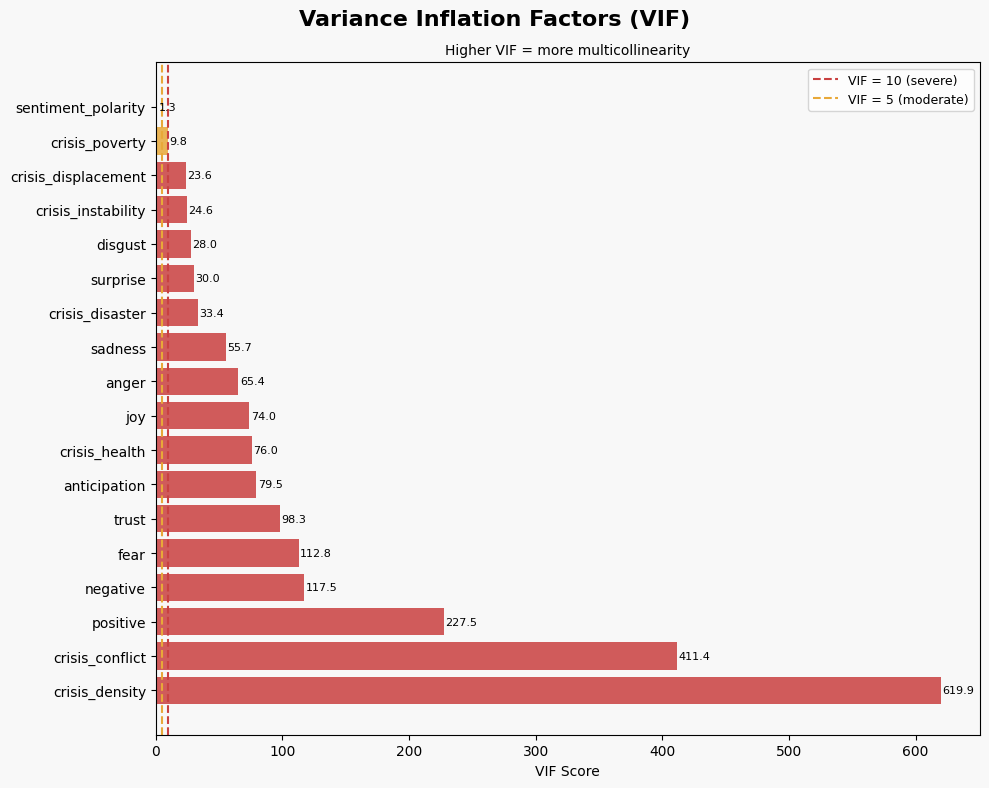

In [20]:
fig, ax = plt.subplots(figsize=(10, 8), facecolor="#F8F8F8")
fig.suptitle("Variance Inflation Factors (VIF)", fontsize=16, fontweight="bold")

colors = ["#C94040" if v > 10 else "#E8A838" if v > 5 else "#4CAF50" for v in vif_results["VIF"]]
bars = ax.barh(vif_results["feature"], vif_results["VIF"], color=colors, alpha=0.85)
ax.axvline(10, color="#C94040", linestyle="--", linewidth=1.5, label="VIF = 10 (severe)")
ax.axvline(5, color="#E8A838", linestyle="--", linewidth=1.5, label="VIF = 5 (moderate)")
ax.set_xlabel("VIF Score")
ax.set_title("Higher VIF = more multicollinearity", fontsize=10)
ax.set_facecolor("#F8F8F8")
ax.legend(fontsize=9)

for bar, val in zip(bars, vif_results["VIF"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

The correlation heatmap and VIF scores reveal severe multicollinearity among the emotion and crisis variables, with VIF scores as high as 620 (crisis_density) and 228 (positive). This rules out standard logistic regression, which assumes independence between predictors. We therefore opt for Lasso regression, which handles multicollinearity through L1 regularisation by shrinking the coefficients of redundant predictors toward zero — preserving interpretability of individual variables while effectively performing feature selection. This is preferable to PCA, which would reduce the correlated variables into uninterpretable components, obscuring the substantive meaning of our predictors.

### Class balance

Class balance check:
global_north_or_south
Global North    191062
Global South     46607
Name: count, dtype: int64

  Ratio: 4.10:1


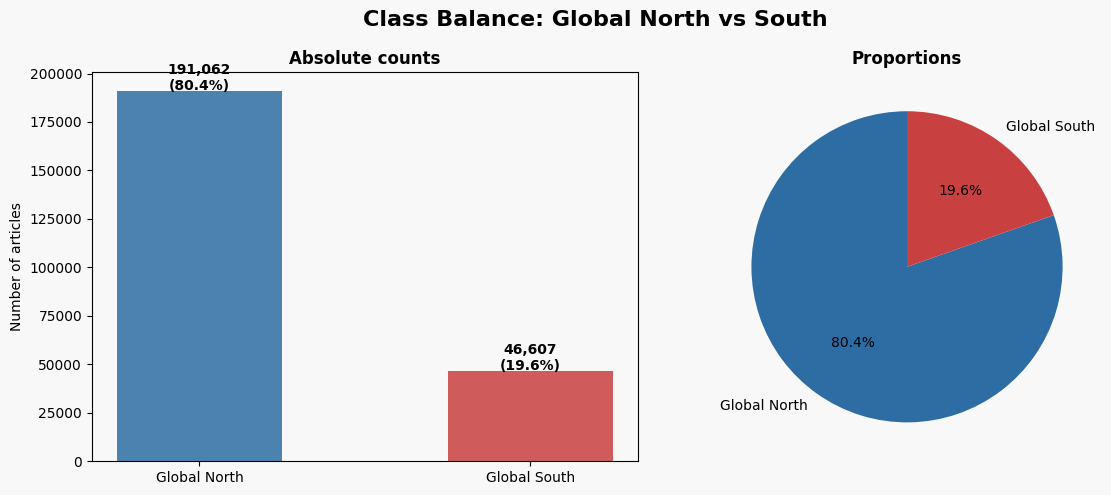

In [21]:
# ── Class balance check ───────────────────────────────────────────────────────
print("Class balance check:")
balance = df["global_north_or_south"].value_counts()
print(balance)
print(f"\n  Ratio: {balance.max() / balance.min():.2f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor="#F8F8F8")
fig.suptitle("Class Balance: Global North vs South", fontsize=16, fontweight="bold")

NORTH_COL = "#2E6DA4"
SOUTH_COL = "#C94040"

# ── Bar chart ─────────────────────────────────────────────────────────────────
ax1 = axes[0]
bars = ax1.bar(balance.index, balance.values, color=[NORTH_COL, SOUTH_COL], alpha=0.85, width=0.5)
ax1.set_ylabel("Number of articles")
ax1.set_title("Absolute counts", fontweight="bold")
ax1.set_facecolor("#F8F8F8")
for bar, val in zip(bars, balance.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f"{val:,}\n({val/len(df)*100:.1f}%)", ha="center", fontsize=10, fontweight="bold")

# ── Pie chart ─────────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.pie(balance.values, labels=balance.index, colors=[NORTH_COL, SOUTH_COL],
        autopct="%1.1f%%", startangle=90)
ax2.set_title("Proportions", fontweight="bold")

plt.tight_layout()
plt.show()

The dataset is significantly imbalanced, with 80.4% of articles covering Global North countries and only 19.6% covering Global South countries. Without correction, models would be biased toward predicting Global North simply due to class frequency rather than meaningful patterns in the data. We address this by setting class_weight='balanced' in all models, which automatically adjusts sample weights inversely proportional to class frequencies, ensuring the model treats both classes equally during training.

### Distributions

Given the nature of our variables, crisis scores that are zero for most articles, emotion scores bounded between 0 and 1, and moral foundation counts that are heavily right-skewed, we expect significant departures from normality in most continuous predictors. We visualise the distributions below to confirm this and discuss implications for modelling.

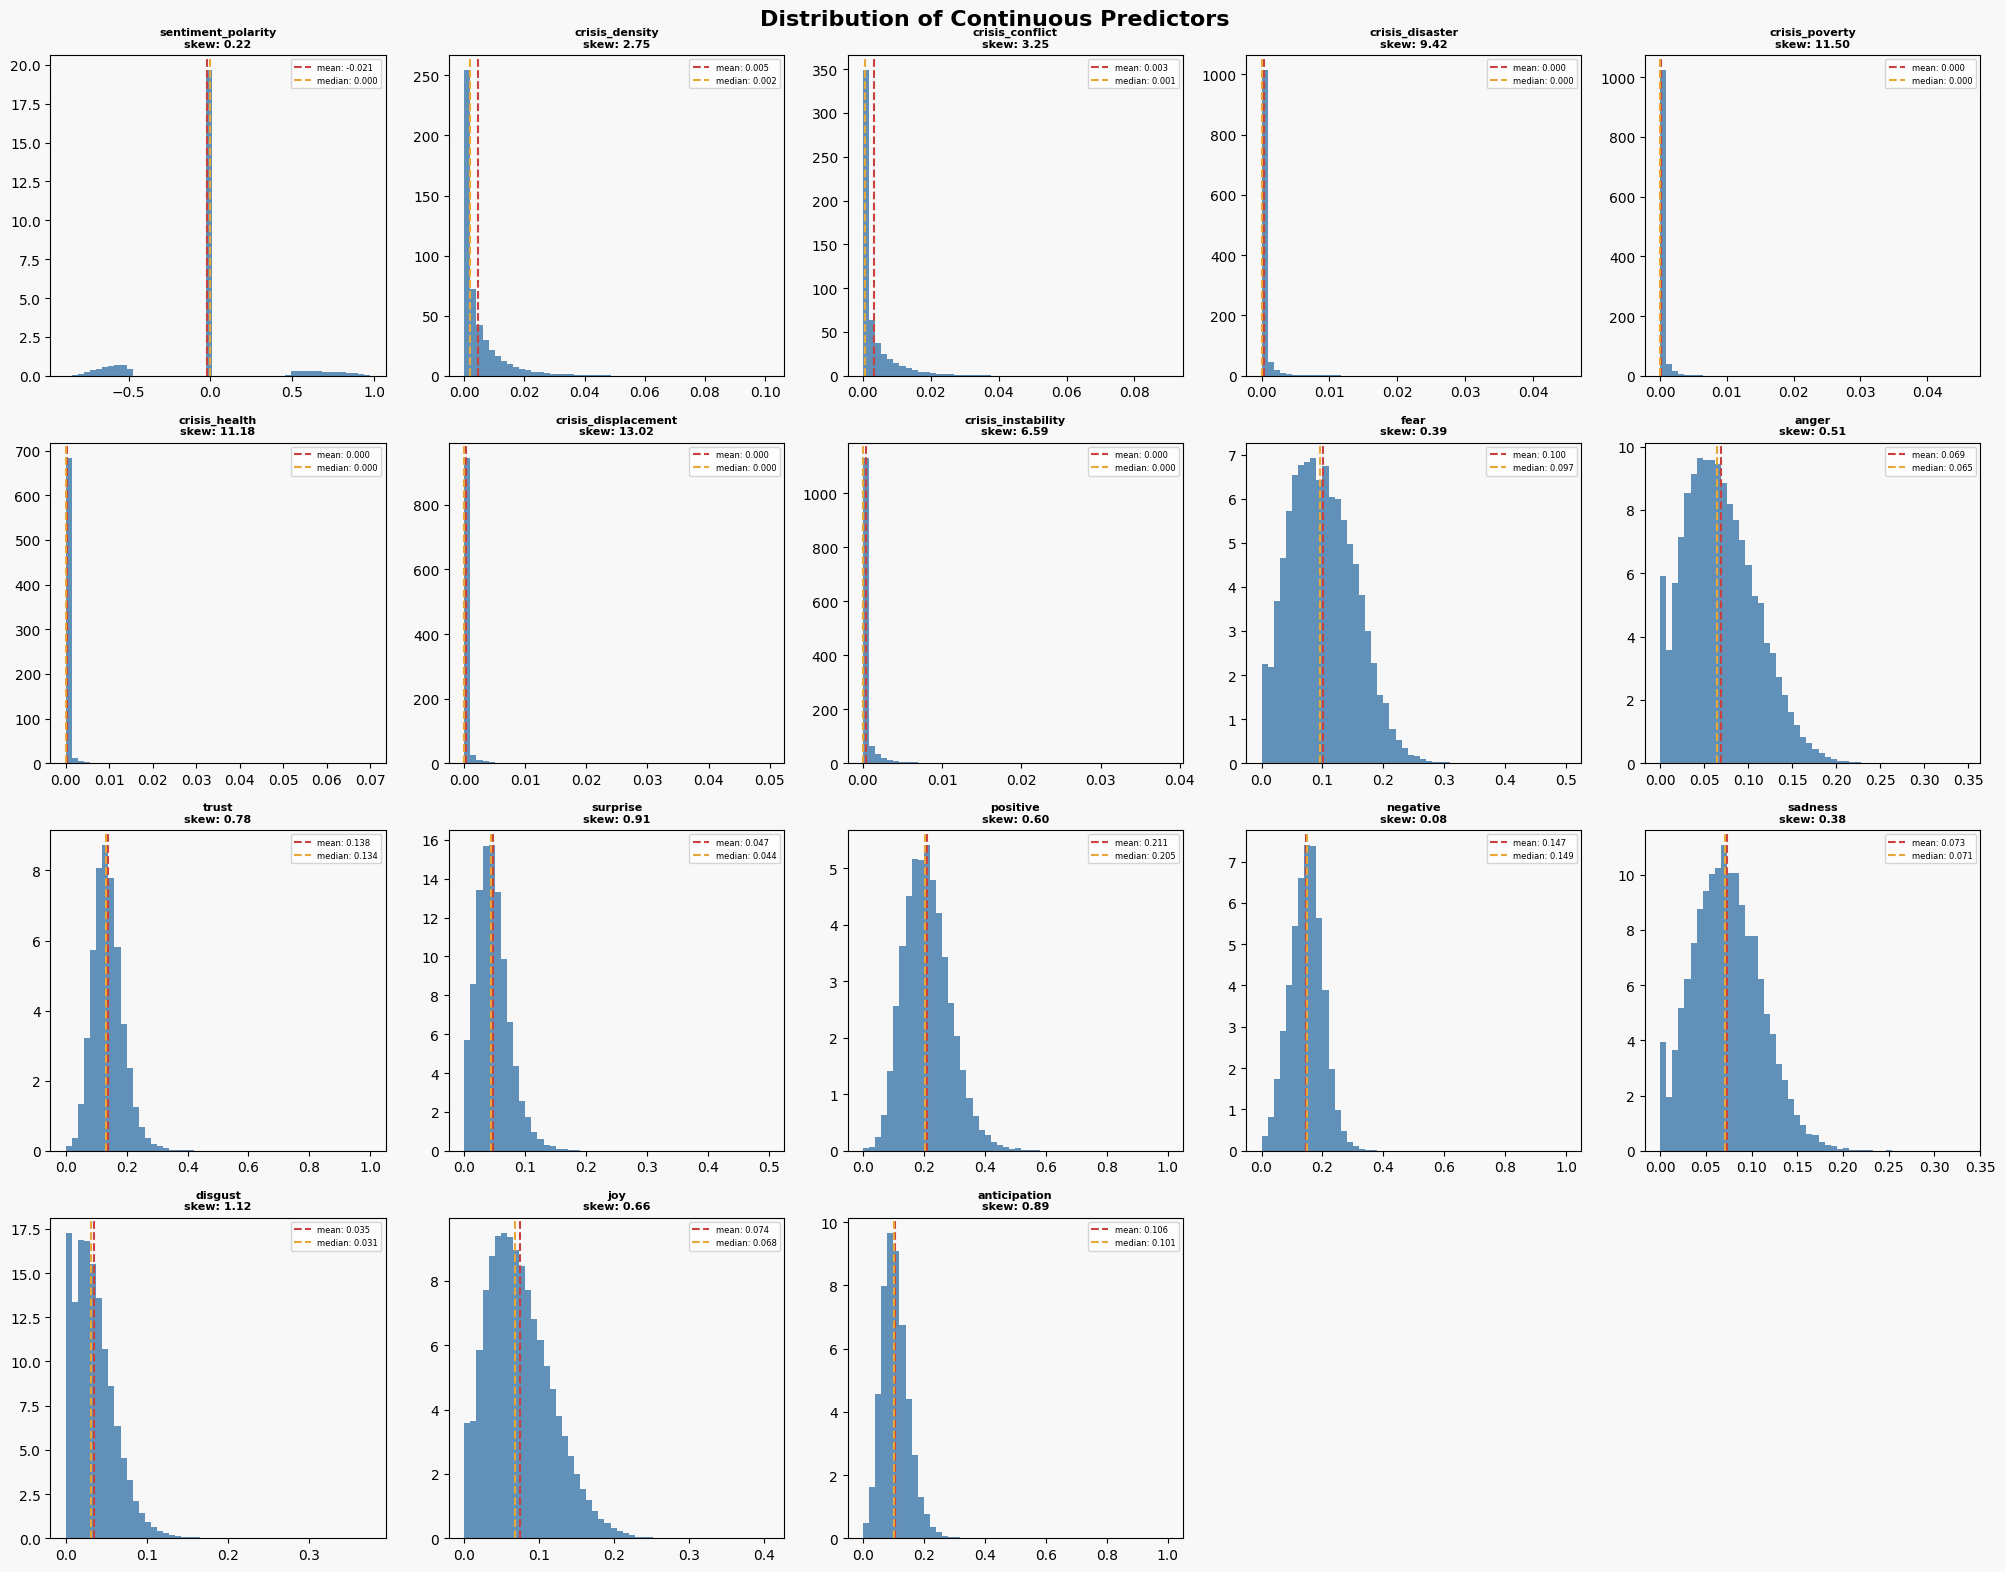

In [22]:
fig, axes = plt.subplots(4, 5, figsize=(20, 16), facecolor="#F8F8F8")
fig.suptitle("Distribution of Continuous Predictors", fontsize=16, fontweight="bold")
axes = axes.flatten()

plot_cols = [
    "sentiment_polarity", "crisis_density", "crisis_conflict", "crisis_disaster",
    "crisis_poverty", "crisis_health", "crisis_displacement", "crisis_instability",
    "fear", "anger", "trust", "surprise", "positive", "negative",
    "sadness", "disgust", "joy", "anticipation"
]

for i, col in enumerate(plot_cols):
    ax = axes[i]
    ax.hist(df[col].dropna(), bins=50, color="#2E6DA4", alpha=0.75, density=True)
    ax.axvline(df[col].mean(), color="#C94040", linestyle="--", linewidth=1.5, label=f"mean: {df[col].mean():.3f}")
    ax.axvline(df[col].median(), color="#E8A838", linestyle="--", linewidth=1.5, label=f"median: {df[col].median():.3f}")
    skew = df[col].skew()
    ax.set_title(f"{col}\nskew: {skew:.2f}", fontsize=8, fontweight="bold")
    ax.set_facecolor("#F8F8F8")
    ax.legend(fontsize=6)

for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

As anticipated, the crisis variables exhibit severe right skew and zero-inflation — the majority of articles contain no crisis language at all, with a small proportion driving the distribution tail. Skew values range from 2.75 (crisis_density) to 13.02 (crisis_displacement). The emotion variables are more moderately skewed, and sentiment_polarity is approximately symmetric (skew = 0.22). These departures from normality are not a concern for our tree-based models (decision tree and random forest), which make no distributional assumptions. For Lasso, sklearn's implementation is robust to non-normality as it optimises a penalised likelihood rather than assuming Gaussian residuals. However, given the large differences in scale across predictors, we standardise all continuous variables before fitting Lasso to ensure the regularisation penalty is applied equally regardless of variable scale

## Modelling

While trade value was included as a structural factor in our exploratory analysis, the scatter plots and correlation heatmap consistently showed weaker relationships with media representation variables compared to HDI (correlations rarely exceeding 0.2 vs up to 0.62 for HDI). We therefore exclude trade value from the modelling stage and treat it as a descriptive variable only. HDI is retained as the continuous structural target for Lasso regression, while global_north_or_south serves as the binary target for Lasso logistic regression, decision tree, and random forest.

### Preprocessing

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ── Define feature set ────────────────────────────────────────────────────────
continuous_features = [
    "crisis_density", "crisis_conflict", "crisis_disaster", "crisis_poverty",
    "crisis_health", "crisis_displacement", "crisis_instability",
    "fear", "anger", "trust", "surprise", "positive", "negative",
    "sadness", "disgust", "joy", "anticipation",
    "authority_virtue", "sanctity_vice", "fairness_virtue", "care_vice",
    "care_virtue", "fairness_vice", "loyalty_virtue", "authority_vice",
    "sanctity_virtue", "loyalty_vice"
]

categorical_features = ["theme", "news_type", "sentiment_label"]

# ── Dummy encode categoricals ─────────────────────────────────────────────────
df_model = pd.get_dummies(df[continuous_features + categorical_features], 
                          columns=categorical_features, 
                          drop_first=True)  # drop_first avoids dummy variable trap

print(f"Features after dummy encoding: {df_model.shape[1]}")
print(f"Dummy encoded columns: {[c for c in df_model.columns if c not in continuous_features]}")

# ── Targets ───────────────────────────────────────────────────────────────────
y_binary = (df["global_north_or_south"] == "Global North").astype(int)  # 1 = North, 0 = South
y_hdi = df["hdi"]

print(f"\nBinary target distribution:\n{y_binary.value_counts()}")

# ── Standardise continuous features ──────────────────────────────────────────
scaler = StandardScaler()
df_model[continuous_features] = scaler.fit_transform(df_model[continuous_features])

# ── Train/test split ──────────────────────────────────────────────────────────
X = df_model
X_train, X_test, y_train_binary, y_test_binary, y_train_hdi, y_test_hdi = train_test_split(
    X, y_binary, y_hdi, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"\nTrain set: {X_train.shape[0]:,} rows")
print(f"Test set:  {X_test.shape[0]:,} rows")
print(f"\nTrain class balance:\n{y_train_binary.value_counts()}")
print(f"\nTest class balance:\n{y_test_binary.value_counts()}")

Features after dummy encoding: 35
Dummy encoded columns: ['theme_Crime & Law', 'theme_Crisis, Disaster & Accidents', 'theme_Culture & Lifestyle', 'theme_Politics & Conflict', 'theme_Sports & Entertainment', 'news_type_Soft news', 'sentiment_label_neutral', 'sentiment_label_positive']

Binary target distribution:
global_north_or_south
1    191062
0     46607
Name: count, dtype: int64

Train set: 190,135 rows
Test set:  47,534 rows

Train class balance:
global_north_or_south
1    152849
0     37286
Name: count, dtype: int64

Test class balance:
global_north_or_south
1    38213
0     9321
Name: count, dtype: int64


Business, Science & Technology and Hard news and sentiment_label_negative are the reference categories that were dropped.

### Model 1: Lasso Logistic Regression
#### Global North / South

In [26]:
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.utils import resample

# ── Step 1: Find best C on a stratified subsample ────────────────────────────
print("Finding best C on subsample...")
X_sub, y_sub = resample(X_train, y_train_binary, 
                         n_samples=30000, 
                         stratify=y_train_binary, 
                         random_state=42)

cv_model = LogisticRegressionCV(
    Cs=10,
    cv=5,
    solver="liblinear",
    l1_ratios=[1.0],
    class_weight="balanced",
    random_state=42,
    max_iter=1000,
    scoring="roc_auc"
)
cv_model.fit(X_sub, y_sub)
best_C = cv_model.C_[0]
print(f"  Best C: {best_C:.4f}")

# ── Step 2: Fit final model on full training set ──────────────────────────────
print("\nFitting final model on full training set...")
lasso_clf = LogisticRegression(
    C=best_C,
    solver="liblinear",
    l1_ratio=1.0,
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)
lasso_clf.fit(X_train, y_train_binary)
print("Done.")

Finding best C on subsample...


c:\Users\czajk\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


  Best C: 2.7826

Fitting final model on full training set...
Done.


Classification Report:
              precision    recall  f1-score   support

Global South       0.36      0.56      0.44      9321
Global North       0.88      0.76      0.82     38213

    accuracy                           0.72     47534
   macro avg       0.62      0.66      0.63     47534
weighted avg       0.78      0.72      0.74     47534

ROC-AUC Score: 0.716
Non-zero coefficients: 35 / 35


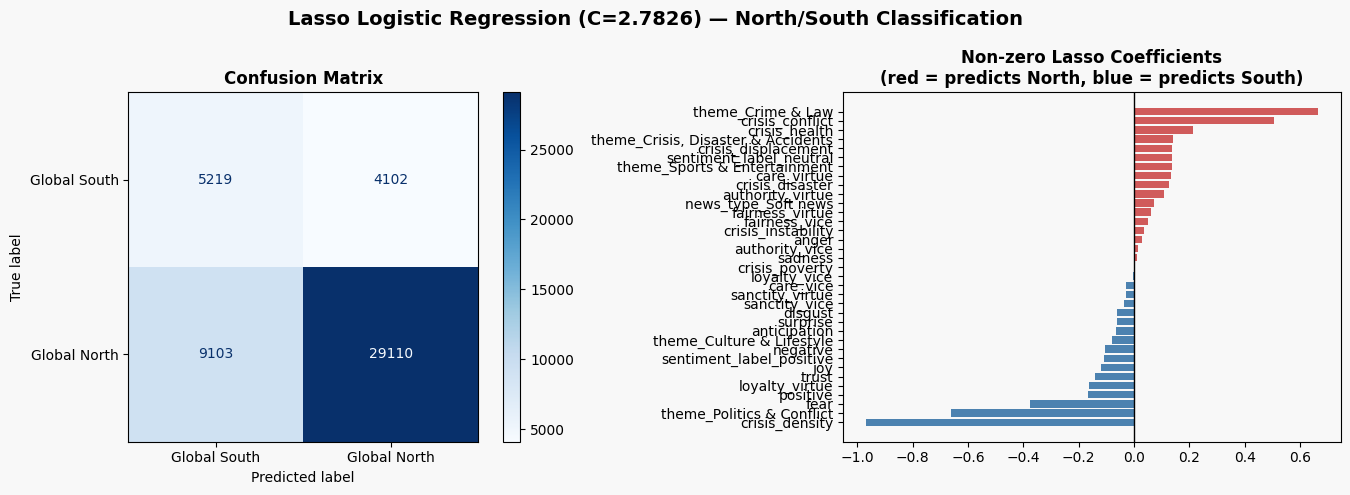

In [27]:
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

# ── Evaluate ──────────────────────────────────────────────────────────────────
y_pred = lasso_clf.predict(X_test)
y_prob = lasso_clf.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test_binary, y_pred, target_names=["Global South", "Global North"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test_binary, y_prob):.3f}")
print(f"Non-zero coefficients: {(lasso_clf.coef_[0] != 0).sum()} / {len(lasso_clf.coef_[0])}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="#F8F8F8")
fig.suptitle(f"Lasso Logistic Regression (C={best_C:.4f}) — North/South Classification", 
             fontsize=14, fontweight="bold")

ax1 = axes[0]
ConfusionMatrixDisplay.from_predictions(y_test_binary, y_pred,
                                        display_labels=["Global South", "Global North"],
                                        cmap="Blues", ax=ax1)
ax1.set_title("Confusion Matrix", fontweight="bold")

ax2 = axes[1]
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": lasso_clf.coef_[0]
}).sort_values("coefficient")
coef_df = coef_df[coef_df["coefficient"] != 0]
colors = ["#C94040" if c > 0 else "#2E6DA4" for c in coef_df["coefficient"]]
ax2.barh(coef_df["feature"], coef_df["coefficient"], color=colors, alpha=0.85)
ax2.axvline(0, color="black", linewidth=1)
ax2.set_title(f"Non-zero Lasso Coefficients\n(red = predicts North, blue = predicts South)", 
              fontweight="bold")
ax2.set_facecolor("#F8F8F8")

plt.tight_layout()
plt.show()

The Lasso logistic regression model achieves a ROC-AUC of 0.716 and an overall accuracy of 72%, with notably higher precision for Global North (0.88) than Global South (0.36), reflecting the difficulty of classifying the minority class even with balanced class weights. Crucially, all 35 features were retained with non-zero coefficients, suggesting that all media representation variables contribute meaningfully to the classification. The strongest predictors of Global South coverage are crisis_density and the Politics & Conflict theme, while Crime & Law and crisis_conflict are the strongest predictors of Global North. This is consistent with our EDA findings and supports the hypothesis that media representation differs systematically between Global North and Global South countries.

#### HDI

Finding best alpha on subsample...
  Best alpha: 0.000149

Fitting final Lasso regression on full training set...
Done.

R² Score: 0.184
RMSE: 0.0963
Non-zero coefficients: 29 / 35


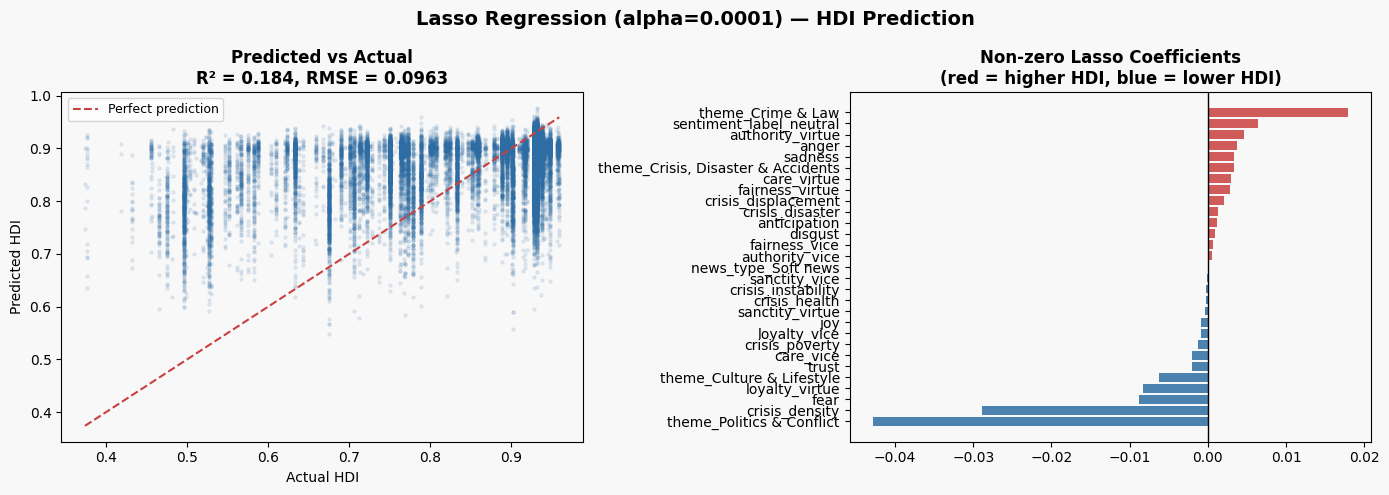

In [30]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_squared_error

# ── Step 1: Find best alpha on a stratified subsample ────────────────────────
print("Finding best alpha on subsample...")
X_sub_hdi, y_sub_hdi = resample(X_train, y_train_hdi,
                                  n_samples=30000,
                                  random_state=42)

lasso_reg_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_reg_cv.fit(X_sub_hdi, y_sub_hdi)
best_alpha = lasso_reg_cv.alpha_
print(f"  Best alpha: {best_alpha:.6f}")

# ── Step 2: Fit final model on full training set ──────────────────────────────
from sklearn.linear_model import Lasso
print("\nFitting final Lasso regression on full training set...")
lasso_reg = Lasso(alpha=best_alpha, max_iter=10000)
lasso_reg.fit(X_train, y_train_hdi)
print("Done.")

# ── Evaluate ──────────────────────────────────────────────────────────────────
y_pred_hdi = lasso_reg.predict(X_test)
r2 = r2_score(y_test_hdi, y_pred_hdi)
rmse = mean_squared_error(y_test_hdi, y_pred_hdi) ** 0.5
print(f"\nR² Score: {r2:.3f}")
print(f"RMSE: {rmse:.4f}")
print(f"Non-zero coefficients: {(lasso_reg.coef_ != 0).sum()} / {len(lasso_reg.coef_)}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="#F8F8F8")
fig.suptitle(f"Lasso Regression (alpha={best_alpha:.4f}) — HDI Prediction",
             fontsize=14, fontweight="bold")

# Predicted vs actual
ax1 = axes[0]
ax1.scatter(y_test_hdi, y_pred_hdi, alpha=0.1, s=5, color="#2E6DA4")
ax1.plot([y_test_hdi.min(), y_test_hdi.max()],
         [y_test_hdi.min(), y_test_hdi.max()],
         color="#C94040", linestyle="--", linewidth=1.5, label="Perfect prediction")
ax1.set_xlabel("Actual HDI")
ax1.set_ylabel("Predicted HDI")
ax1.set_title(f"Predicted vs Actual\nR² = {r2:.3f}, RMSE = {rmse:.4f}", fontweight="bold")
ax1.legend(fontsize=9)
ax1.set_facecolor("#F8F8F8")

# Coefficients
ax2 = axes[1]
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": lasso_reg.coef_
}).sort_values("coefficient")
coef_df = coef_df[coef_df["coefficient"] != 0]
colors = ["#C94040" if c > 0 else "#2E6DA4" for c in coef_df["coefficient"]]
ax2.barh(coef_df["feature"], coef_df["coefficient"], color=colors, alpha=0.85)
ax2.axvline(0, color="black", linewidth=1)
ax2.set_title("Non-zero Lasso Coefficients\n(red = higher HDI, blue = lower HDI)",
              fontweight="bold")
ax2.set_facecolor("#F8F8F8")

plt.tight_layout()
plt.show()

The Lasso regression model predicting HDI achieves an R² of 0.184 and an RMSE of 0.096, meaning media representation variables explain approximately 18% of the variance in a country's HDI. While modest, this is a meaningful result given that we are predicting a structural country-level characteristic purely from article-level textual features. Lasso retained 29 of 35 features, successfully performing feature selection. The predicted vs actual plot reveals a characteristic vertical striping pattern, reflecting the fact that HDI is a country-level variable — all articles about the same country share the same HDI value, creating discrete bands in the predictions. The coefficient pattern is consistent with our EDA findings: Politics & Conflict coverage and high crisis density are the strongest predictors of lower HDI, while Crime & Law coverage and neutral sentiment are associated with higher HDI countries.

### Model 2: Decision tree

#### Without pruning

In [31]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

# ── Decision Tree ─────────────────────────────────────────────────────────────
print("Fitting Decision Tree...")

dt = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)
dt.fit(X_train, y_train_binary)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("Classification Report (unpruned):")
print(classification_report(y_test_binary, y_pred_dt, target_names=["Global South", "Global North"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test_binary, y_prob_dt):.3f}")
print(f"Tree depth: {dt.get_depth()}")
print(f"Number of leaves: {dt.get_n_leaves()}")

Fitting Decision Tree...
Classification Report (unpruned):
              precision    recall  f1-score   support

Global South       0.34      0.34      0.34      9321
Global North       0.84      0.84      0.84     38213

    accuracy                           0.74     47534
   macro avg       0.59      0.59      0.59     47534
weighted avg       0.74      0.74      0.74     47534

ROC-AUC Score: 0.590
Tree depth: 57
Number of leaves: 30158


#### With pruning


Finding optimal ccp_alpha via cost-complexity pruning...
  Best ccp_alpha: 0.000556


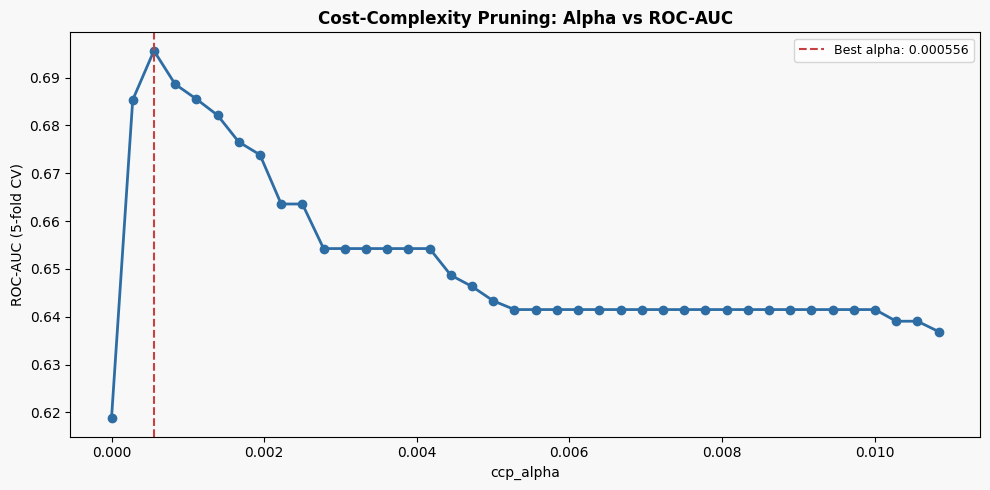

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

print("Finding optimal ccp_alpha via cost-complexity pruning...")

X_sub_dt, y_sub_dt = resample(X_train, y_train_binary,
                               n_samples=30000,
                               stratify=y_train_binary,
                               random_state=42)

path = DecisionTreeClassifier(class_weight="balanced", random_state=42).cost_complexity_pruning_path(X_sub_dt, y_sub_dt)
ccp_alphas = path.ccp_alphas[:-1]

# Test 40 evenly spaced values across the full pruning path range
ccp_alphas_subset = np.linspace(ccp_alphas.min(), ccp_alphas.max(), 40)

cv_scores = []
for alpha in ccp_alphas_subset:
    dt_cv = DecisionTreeClassifier(ccp_alpha=alpha, class_weight="balanced", random_state=42)
    scores = cross_val_score(dt_cv, X_sub_dt, y_sub_dt, cv=5, scoring="roc_auc")
    cv_scores.append(scores.mean())

best_alpha_dt = ccp_alphas_subset[np.argmax(cv_scores)]
print(f"  Best ccp_alpha: {best_alpha_dt:.6f}")

fig, ax = plt.subplots(figsize=(10, 5), facecolor="#F8F8F8")
ax.plot(ccp_alphas_subset, cv_scores, marker="o", color="#2E6DA4", linewidth=2)
ax.axvline(best_alpha_dt, color="#C94040", linestyle="--", linewidth=1.5,
           label=f"Best alpha: {best_alpha_dt:.6f}")
ax.set_xlabel("ccp_alpha")
ax.set_ylabel("ROC-AUC (5-fold CV)")
ax.set_title("Cost-Complexity Pruning: Alpha vs ROC-AUC", fontweight="bold")
ax.legend(fontsize=9)
ax.set_facecolor("#F8F8F8")
plt.tight_layout()
plt.show()

To address the overfitting of the unpruned decision tree (depth 57, 30,158 leaves), we apply cost-complexity pruning to find the optimal tree complexity. The pruning parameter ccp_alpha controls the trade-off between tree size and fit — higher values result in more aggressive pruning. We select the optimal alpha through 5-fold cross-validation on a stratified subsample, evaluating ROC-AUC at 40 evenly spaced alpha values across the full pruning path. The curve shows a clear peak at alpha = 0.000556, beyond which performance degrades as the tree becomes too simple to capture meaningful patterns in the data.

Fitting pruned decision tree...
Classification Report (pruned):
              precision    recall  f1-score   support

Global South       0.46      0.43      0.45      9321
Global North       0.86      0.88      0.87     38213

    accuracy                           0.79     47534
   macro avg       0.66      0.65      0.66     47534
weighted avg       0.78      0.79      0.79     47534

ROC-AUC Score: 0.693
Tree depth: 5
Number of leaves: 11


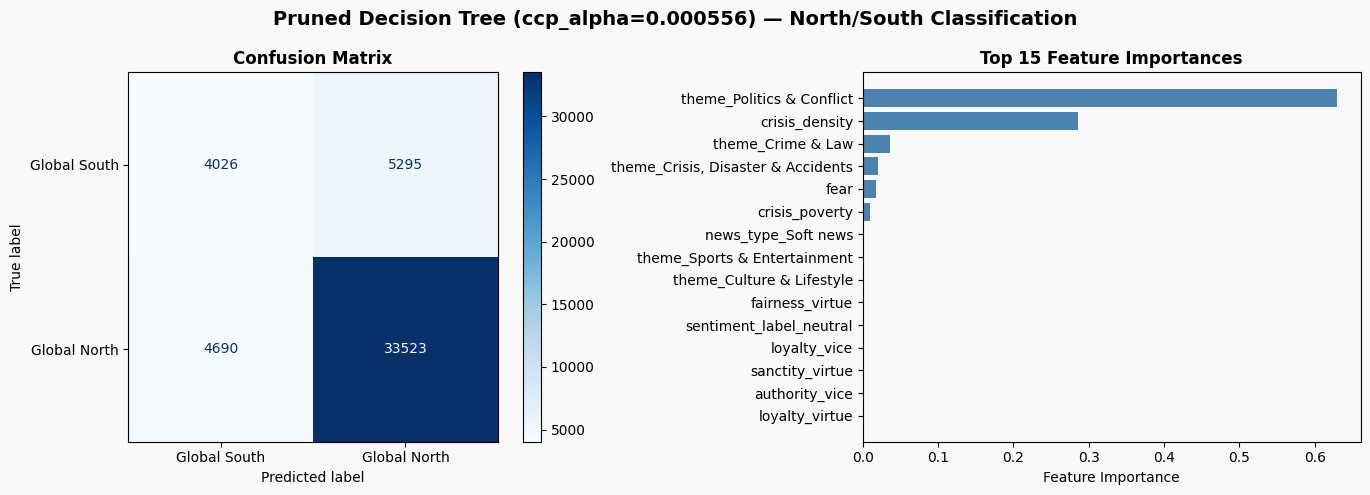

In [36]:
# ── Fit pruned decision tree ───────────────────────────────────────────────────
print("Fitting pruned decision tree...")

dt_pruned = DecisionTreeClassifier(
    ccp_alpha=best_alpha_dt,
    class_weight="balanced",
    random_state=42
)
dt_pruned.fit(X_train, y_train_binary)

y_pred_dt_pruned = dt_pruned.predict(X_test)
y_prob_dt_pruned = dt_pruned.predict_proba(X_test)[:, 1]

print("Classification Report (pruned):")
print(classification_report(y_test_binary, y_pred_dt_pruned, target_names=["Global South", "Global North"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test_binary, y_prob_dt_pruned):.3f}")
print(f"Tree depth: {dt_pruned.get_depth()}")
print(f"Number of leaves: {dt_pruned.get_n_leaves()}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="#F8F8F8")
fig.suptitle(f"Pruned Decision Tree (ccp_alpha={best_alpha_dt:.6f}) — North/South Classification",
             fontsize=14, fontweight="bold")

ax1 = axes[0]
ConfusionMatrixDisplay.from_predictions(y_test_binary, y_pred_dt_pruned,
                                        display_labels=["Global South", "Global North"],
                                        cmap="Blues", ax=ax1)
ax1.set_title("Confusion Matrix", fontweight="bold")

# Feature importance
ax2 = axes[1]
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": dt_pruned.feature_importances_
}).sort_values("importance", ascending=False).head(15)
ax2.barh(importance_df["feature"][::-1], importance_df["importance"][::-1],
         color="#2E6DA4", alpha=0.85)
ax2.set_xlabel("Feature Importance")
ax2.set_title("Top 15 Feature Importances", fontweight="bold")
ax2.set_facecolor("#F8F8F8")

plt.tight_layout()
plt.show()

The unpruned decision tree severely overfits the training data, reaching a depth of 57 with 30,158 leaves and achieving a ROC-AUC of only 0.590 on the test set. After applying cost-complexity pruning with the optimal alpha of 0.000556, the tree is reduced to a depth of 5 with just 11 leaves, and ROC-AUC improves substantially to 0.693. This demonstrates the importance of pruning for generalisation. The feature importance plot reveals that the model relies almost entirely on two variables: theme_Politics & Conflict (0.62) and crisis_density (0.29), consistent with our EDA findings that these are the strongest differentiators between Global North and Global South coverage. The pruned tree's simplicity also makes it highly interpretable — with only 5 decision levels, each classification path can be fully traced and explained.

### Model 3: Random Forest

Fitting Random Forest...
Classification Report:
              precision    recall  f1-score   support

Global South       0.71      0.24      0.36      9321
Global North       0.84      0.98      0.90     38213

    accuracy                           0.83     47534
   macro avg       0.77      0.61      0.63     47534
weighted avg       0.81      0.83      0.80     47534

ROC-AUC Score: 0.747


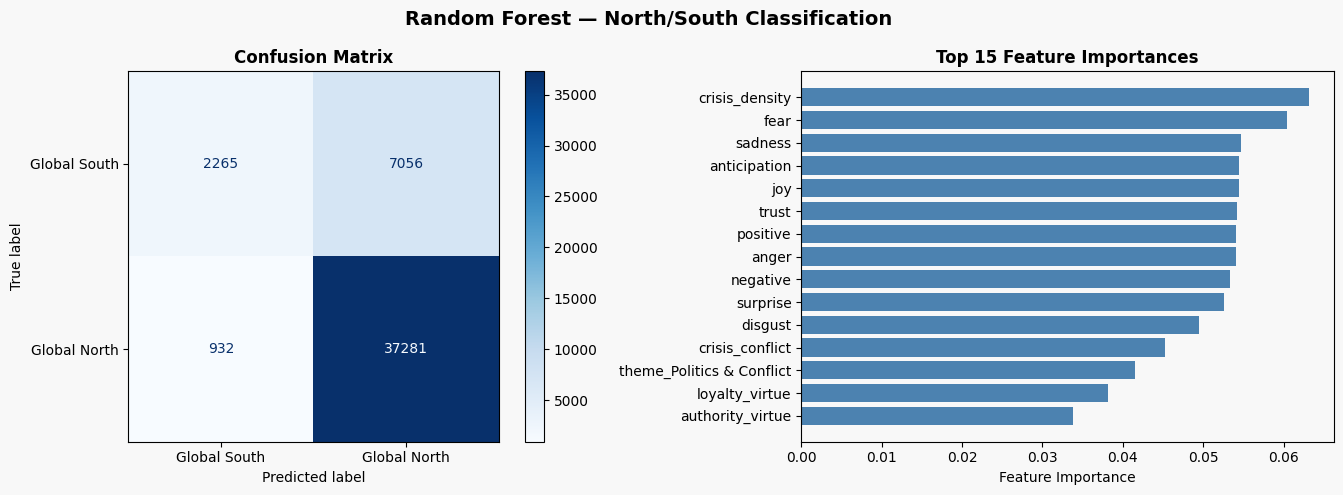

In [37]:
from sklearn.ensemble import RandomForestClassifier

# ── Random Forest ─────────────────────────────────────────────────────────────
print("Fitting Random Forest...")

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train_binary)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test_binary, y_pred_rf, target_names=["Global South", "Global North"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test_binary, y_prob_rf):.3f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="#F8F8F8")
fig.suptitle("Random Forest — North/South Classification", fontsize=14, fontweight="bold")

ax1 = axes[0]
ConfusionMatrixDisplay.from_predictions(y_test_binary, y_pred_rf,
                                        display_labels=["Global South", "Global North"],
                                        cmap="Blues", ax=ax1)
ax1.set_title("Confusion Matrix", fontweight="bold")

ax2 = axes[1]
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).head(15)
ax2.barh(importance_df["feature"][::-1], importance_df["importance"][::-1],
         color="#2E6DA4", alpha=0.85)
ax2.set_xlabel("Feature Importance")
ax2.set_title("Top 15 Feature Importances", fontweight="bold")
ax2.set_facecolor("#F8F8F8")

plt.tight_layout()
plt.show()

The initial random forest achieves a ROC-AUC of 0.747, outperforming both the Lasso logistic regression (0.716) and the pruned decision tree (0.693). However, with no constraint on tree depth, the model grows trees to their full complexity which may lead to overfitting. We therefore tune the max_depth parameter through 5-fold cross-validation on a stratified subsample to find the optimal trade-off between complexity and generalisation.

Tuning max_depth for Random Forest...
  max_depth=   3 — ROC-AUC: 0.692
  max_depth=   5 — ROC-AUC: 0.706
  max_depth=  10 — ROC-AUC: 0.731
  max_depth=  15 — ROC-AUC: 0.742
  max_depth=  20 — ROC-AUC: 0.749
  max_depth=  25 — ROC-AUC: 0.759
  max_depth=  30 — ROC-AUC: 0.759
  max_depth=None — ROC-AUC: 0.759

  Best max_depth: None


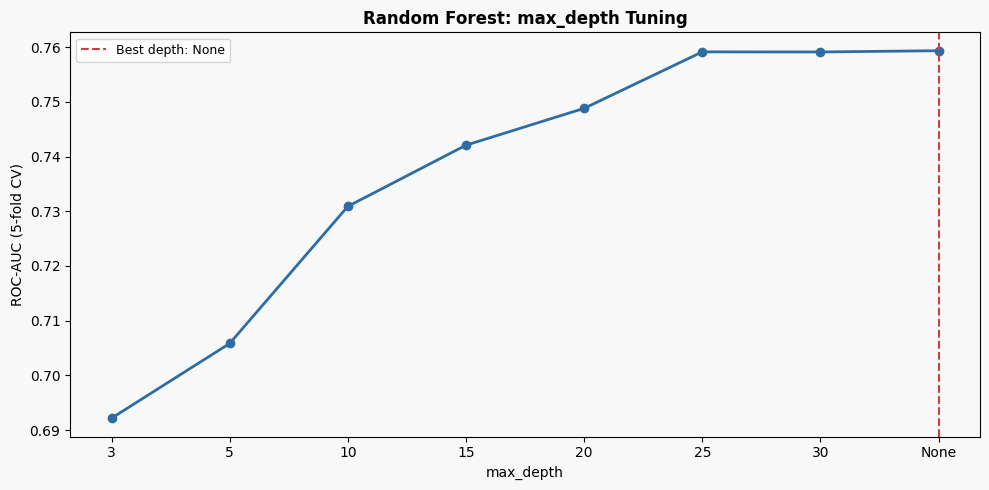

In [38]:
from sklearn.model_selection import cross_val_score

# ── Tune max_depth via cross-validation on subsample ─────────────────────────
print("Tuning max_depth for Random Forest...")

X_sub_rf, y_sub_rf = resample(X_train, y_train_binary,
                               n_samples=30000,
                               stratify=y_train_binary,
                               random_state=42)

depths = [3, 5, 10, 15, 20, 25, 30, None]
cv_scores_rf = []

for depth in depths:
    rf_cv = RandomForestClassifier(
        n_estimators=50,
        max_depth=depth,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    scores = cross_val_score(rf_cv, X_sub_rf, y_sub_rf, cv=5, scoring="roc_auc")
    cv_scores_rf.append(scores.mean())
    print(f"  max_depth={str(depth):>4} — ROC-AUC: {scores.mean():.3f}")

best_depth = depths[np.argmax(cv_scores_rf)]
print(f"\n  Best max_depth: {best_depth}")

fig, ax = plt.subplots(figsize=(10, 5), facecolor="#F8F8F8")
ax.plot([str(d) for d in depths], cv_scores_rf, marker="o", color="#2E6DA4", linewidth=2)
ax.axvline(str(best_depth), color="#C94040", linestyle="--", linewidth=1.5,
           label=f"Best depth: {best_depth}")
ax.set_xlabel("max_depth")
ax.set_ylabel("ROC-AUC (5-fold CV)")
ax.set_title("Random Forest: max_depth Tuning", fontweight="bold")
ax.legend(fontsize=9)
ax.set_facecolor("#F8F8F8")
plt.tight_layout()
plt.show()

The cross-validation results show that ROC-AUC plateaus at max_depth=25, with depths of 25, 30, and unconstrained trees all achieving 0.759. We therefore set max_depth=25 explicitly — it produces identical performance to an unconstrained tree while imposing a principled limit on complexity, reducing the risk of overfitting. We refit the final random forest with this constraint on the full training set.

Fitting final Random Forest (max_depth=25)...
Classification Report:
              precision    recall  f1-score   support

Global South       0.65      0.29      0.40      9321
Global North       0.85      0.96      0.90     38213

    accuracy                           0.83     47534
   macro avg       0.75      0.63      0.65     47534
weighted avg       0.81      0.83      0.80     47534

ROC-AUC Score: 0.740


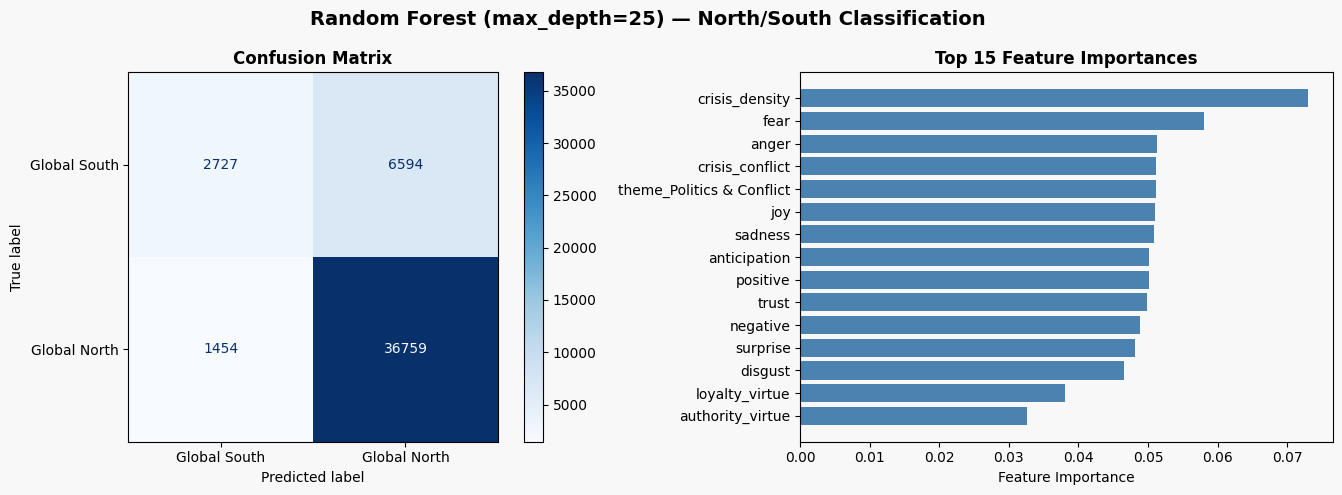

In [39]:
# ── Final Random Forest with max_depth=25 ─────────────────────────────────────
print("Fitting final Random Forest (max_depth=25)...")

rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=25,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train, y_train_binary)

y_pred_rf_final = rf_final.predict(X_test)
y_prob_rf_final = rf_final.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test_binary, y_pred_rf_final, target_names=["Global South", "Global North"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test_binary, y_prob_rf_final):.3f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="#F8F8F8")
fig.suptitle("Random Forest (max_depth=25) — North/South Classification",
             fontsize=14, fontweight="bold")

ax1 = axes[0]
ConfusionMatrixDisplay.from_predictions(y_test_binary, y_pred_rf_final,
                                        display_labels=["Global South", "Global North"],
                                        cmap="Blues", ax=ax1)
ax1.set_title("Confusion Matrix", fontweight="bold")

ax2 = axes[1]
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_final.feature_importances_
}).sort_values("importance", ascending=False).head(15)
ax2.barh(importance_df["feature"][::-1], importance_df["importance"][::-1],
         color="#2E6DA4", alpha=0.85)
ax2.set_xlabel("Feature Importance")
ax2.set_title("Top 15 Feature Importances", fontweight="bold")
ax2.set_facecolor("#F8F8F8")

plt.tight_layout()
plt.show()

The final random forest with max_depth=25 achieves a ROC-AUC of 0.740, comparable to the unconstrained model (0.747) while imposing a principled limit on complexity. The model classifies Global North articles well (recall 0.96) but struggles with Global South (recall 0.29), reflecting the class imbalance challenge. Unlike the pruned decision tree which relied almost entirely on theme_Politics & Conflict, the random forest distributes importance across crisis_density, fear, anger, and multiple emotion variables, capturing a richer and more nuanced picture of what distinguishes North from South coverage.

## Model comparison

                        Model  ROC-AUC  Accuracy  South Precision  South Recall  North Precision  North Recall
    Lasso Logistic Regression    0.716      0.72             0.36          0.56             0.88          0.76
         Pruned Decision Tree    0.693      0.79             0.46          0.43             0.86          0.88
Random Forest (unconstrained)    0.747      0.83             0.71          0.24             0.84          0.98
 Random Forest (max_depth=25)    0.740      0.83             0.65          0.29             0.85          0.96


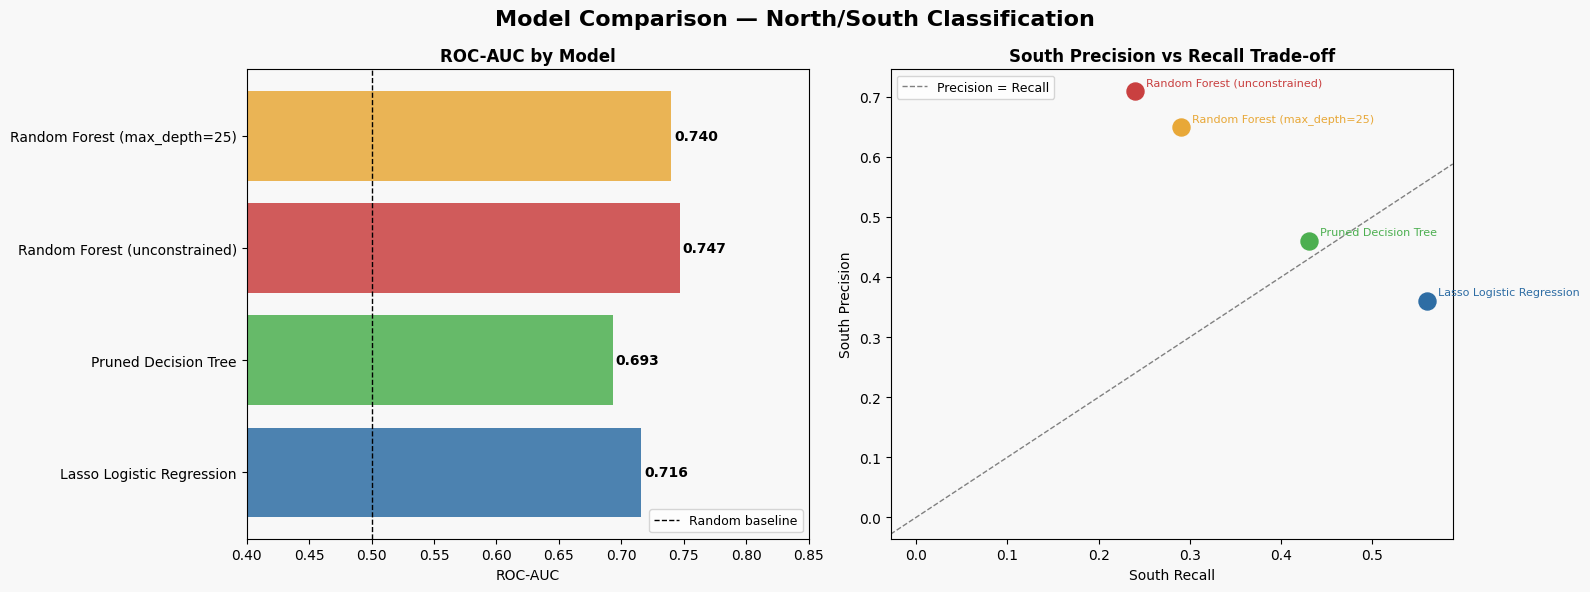

In [40]:
# ── Model Comparison ──────────────────────────────────────────────────────────
results = pd.DataFrame({
    "Model": [
        "Lasso Logistic Regression",
        "Pruned Decision Tree",
        "Random Forest (unconstrained)",
        "Random Forest (max_depth=25)"
    ],
    "ROC-AUC": [0.716, 0.693, 0.747, 0.740],
    "Accuracy": [0.72, 0.79, 0.83, 0.83],
    "South Precision": [0.36, 0.46, 0.71, 0.65],
    "South Recall": [0.56, 0.43, 0.24, 0.29],
    "North Precision": [0.88, 0.86, 0.84, 0.85],
    "North Recall": [0.76, 0.88, 0.98, 0.96]
})

print(results.to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor="#F8F8F8")
fig.suptitle("Model Comparison — North/South Classification", fontsize=16, fontweight="bold")

colors = ["#2E6DA4", "#4CAF50", "#C94040", "#E8A838"]

# ROC-AUC comparison
ax1 = axes[0]
bars = ax1.barh(results["Model"], results["ROC-AUC"], color=colors, alpha=0.85)
ax1.axvline(0.5, color="black", linestyle="--", linewidth=1, label="Random baseline")
ax1.set_xlabel("ROC-AUC")
ax1.set_title("ROC-AUC by Model", fontweight="bold")
ax1.set_xlim(0.4, 0.85)
ax1.set_facecolor("#F8F8F8")
ax1.legend(fontsize=9)
for bar, val in zip(bars, results["ROC-AUC"]):
    ax1.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=10, fontweight="bold")

# South recall vs precision trade-off
ax2 = axes[1]
for i, (model, prec, rec, color) in enumerate(zip(
        results["Model"], results["South Precision"], results["South Recall"], colors)):
    ax2.scatter(rec, prec, color=color, s=150, zorder=5)
    ax2.annotate(model, (rec, prec), textcoords="offset points",
                xytext=(8, 4), fontsize=8, color=color)
ax2.set_xlabel("South Recall")
ax2.set_ylabel("South Precision")
ax2.set_title("South Precision vs Recall Trade-off", fontweight="bold")
ax2.set_facecolor("#F8F8F8")
ax2.axline((0, 0), slope=1, color="gray", linestyle="--", linewidth=1, label="Precision = Recall")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

Across all four models, the random forest variants achieve the highest ROC-AUC (0.747 and 0.740), followed by Lasso logistic regression (0.716) and the pruned decision tree (0.693). However, ROC-AUC alone does not tell the full story — the precision-recall trade-off for Global South reveals meaningful differences between models. The random forests achieve high South precision (0.65-0.71) but low recall (0.24-0.29), meaning they are conservative in predicting South but miss many actual South articles. Lasso logistic regression strikes the best balance, with the highest South recall (0.56) at the cost of lower precision (0.36). The pruned decision tree sits in between (precision 0.46, recall 0.43). The choice of best model therefore depends on the research priority: if correctly identifying Global South coverage is the goal, Lasso is preferable; if overall discrimination is the priority, random forest is stronger. Across all models, crisis_density, fear, and theme_Politics & Conflict consistently emerge as the most important predictors, reinforcing the finding that Global South countries are systematically represented through a lens of crisis and conflict in Western media.